<a href="https://colab.research.google.com/github/Arifemreak/scivector/blob/main/Scientific_Expertise_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Veri Hazırlama (Biomedical Abstracts)
2. Embedding Extraction (Sentence-Transformers)
3. Cosine Similarity Matrix Oluşturma
4. Graph Construction (NetworkX)
5. Graph Metrics + Community Detection (Louvain, Label Propagation vs.)
6. Expertise Labeling (Cluster merkezlerinden keyword extraction)
7. Visualization (Graph Plotting, Cluster Colors)
8. Open Science Mapping açıklaması (markdown hücrelerinde proje raporu)
9. Final Export (Colab dosyasını GitHub'a yükleme için hazırlanmış şekilde)


In [1]:
import pandas as pd
df = pd.read_csv('/content/processed_abstracts.csv')
# 2. Veri setinin boyutuna bakalım
print(f"Toplam kayıt sayısı: {len(df)}")
print(df.columns)

# 3. İlk 5 kaydı görelim
df.head()

Toplam kayıt sayısı: 978
Index(['Abstract', 'Domain', 'Cleaned_Abstract', 'Domain_Final'], dtype='object')


,Abstract,Domain,Cleaned_Abstract,Domain_Final
0,Celastrol has been shown to inhibit hepatocell...,AI in Oncology,celastrol shown inhibit hepatocellular carcino...,AI in Oncology
1,There is limited data on health-related qualit...,AI in Oncology,limited data healthrelated quality life hrqol ...,AI in Oncology
2,The acquired resistance to existing therapies ...,AI in Oncology,acquired resistance existing therapies poses g...,AI in Oncology
3,Liquid biopsies are an increasingly important ...,AI in Oncology,liquid biopsies increasingly important tool re...,AI in Oncology
4,Eradication of inhibitors is still a desirable...,AI in Oncology,eradication inhibitors still desirable goal he...,AI in Oncology


In [2]:
print("Kolonlar:", df.columns.tolist())

# 3. İlk 5 kaydı görelim
df.head()

# 4. Sadece Cleaned_Abstract kolonunu alalım
abstracts = df['Cleaned_Abstract'].dropna().tolist()

# 5. İlk 3 özet örneği
for i, abs_text in enumerate(abstracts[:3], 1):
    print(f"\nÖzet {i}: {abs_text}")

Kolonlar: ['Abstract', 'Domain', 'Cleaned_Abstract', 'Domain_Final']

Özet 1: celastrol shown inhibit hepatocellular carcinoma hcc progression underlying mechanism unknown fanconi anemia complementation group ifancdi ferroptosis inhibitor promotes hcc proliferation invasion study aims investigate whether celastrol exerts effects targeting ifancdi using data cancer genome atlas tcga identified differentially expressed genes hcc utilizing gene expression profiling interactive analysis gepia ifancdi celastrol analyzed molecular docking using autodock based geometric matching energy matching correlation ifancdi survival rate analyzed using kaplanmeiers estimates logrank mantelcox test hcc cell lines snu snu overexpressed silenced ifancdi treated celastrol autophagy ferroptosis evaluated measuring oxidative stress related markers cell function experiments performed high expression ifancdi correlated poor survival hcc patients celastrol targeted ifancdi reducing level snu snu cells ifancdi o

In [3]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer

# 1. Modeli yükle
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Embed işlemi
embeddings = model.encode(abstracts, show_progress_bar=True)

# 3. Embed boyut kontrolü
import numpy as np
embeddings = np.array(embeddings)
print("Embedding shape:", embeddings.shape)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.2 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Embedding shape: (978, 384)


In [4]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Cosine Similarity Matrisi hesapla
similarity_matrix = cosine_similarity(embeddings)

# 2. Matrix boyutunu kontrol edelim
print("Similarity matrix shape:", similarity_matrix.shape)

# 3. Birkaç örnek similarity değerine bakalım
print("İlk 5 similarity değerleri (kendisiyle ve ilk 5 komşusuyla):")
print(similarity_matrix[0][:5])


Similarity matrix shape: (978, 978)
İlk 5 similarity değerleri (kendisiyle ve ilk 5 komşusuyla):
[1.0000001  0.30267274 0.4112264  0.36751878 0.40220654]


In [5]:
import networkx as nx

# 1. Graph nesnesi oluştur
G = nx.Graph()

# 2. Node'ları ekle (0'dan 977'ye kadar id'lerimiz var)
G.add_nodes_from(range(len(abstracts)))

# 3. Threshold belirle
threshold = 0.5

# 4. Similarity matrix üzerinden edge ekleme
for i in range(len(abstracts)):
    for j in range(i+1, len(abstracts)):  # j>i ile tekrar etmeyelim
        if similarity_matrix[i, j] >= threshold:
            G.add_edge(i, j, weight=similarity_matrix[i, j])

# 5. Graph bilgisi
print(f"Toplam Node Sayısı: {G.number_of_nodes()}")
print(f"Toplam Edge Sayısı: {G.number_of_edges()}")


Toplam Node Sayısı: 978
Toplam Edge Sayısı: 28681


In [6]:
!pip install -q python-louvain

import community.community_louvain as community_louvain
# 1. Louvain community detection
partition = community_louvain.best_partition(G, weight='weight')

# 2. Her node'un ait olduğu cluster'ı gösterelim
print(f"Örnek partition (ilk 10 node):")
for node in list(partition.keys())[:10]:
    print(f"Node {node}: Cluster {partition[node]}")

# 3. Toplam kaç farklı cluster oluşmuş
num_clusters = len(set(partition.values()))
print(f"Toplam Cluster Sayısı: {num_clusters}")


Örnek partition (ilk 10 node):
Node 0: Cluster 0
Node 1: Cluster 1
Node 2: Cluster 0
Node 3: Cluster 1
Node 4: Cluster 1
Node 5: Cluster 1
Node 6: Cluster 1
Node 7: Cluster 2
Node 8: Cluster 1
Node 9: Cluster 0
Toplam Cluster Sayısı: 30


In [7]:
from collections import defaultdict
import numpy as np

# 1. Cluster -> Node ID listesi oluştur
cluster_to_nodes = defaultdict(list)
for node, cluster_id in partition.items():
    cluster_to_nodes[cluster_id].append(node)

# 2. Cluster centroid'lerini hesaplayalım
cluster_centroids = {}

for cluster_id, nodes in cluster_to_nodes.items():
    cluster_embeddings = embeddings[nodes]
    centroid = np.mean(cluster_embeddings, axis=0)
    cluster_centroids[cluster_id] = centroid

print(f"Toplam {len(cluster_centroids)} cluster centroid hesaplandı.")


Toplam 30 cluster centroid hesaplandı.


In [8]:
# Cluster için en temsili özetleri bulalım (centroid'e en yakın olanlar)

from sklearn.metrics.pairwise import cosine_similarity

# Her cluster için en yakın 3 özet
cluster_representatives = {}

for cluster_id, nodes in cluster_to_nodes.items():
    cluster_embeds = embeddings[nodes]
    centroid = cluster_centroids[cluster_id].reshape(1, -1)

    similarities = cosine_similarity(centroid, cluster_embeds)[0]
    top_indices = np.argsort(similarities)[-3:][::-1]  # En yakın 3 özet (en yüksek similarity)

    representative_nodes = [nodes[i] for i in top_indices]
    cluster_representatives[cluster_id] = representative_nodes

# Örnek çıktı: İlk 5 cluster için en temsili özetler
for cluster_id in list(cluster_representatives.keys())[:5]:
    print(f"\nCluster {cluster_id}:")
    for node_id in cluster_representatives[cluster_id]:
        print(f"- Node {node_id}: {abstracts[node_id][:200]}...")  # Özetin ilk 200 karakterini gösterelim



Cluster 0:
- Node 118: pdl immune checkpoint inhibitor vegfr essential cancer metastasis play pivotal roles tumorigenesis however miniature bispecific intracellular nanobodies combining checkpoint blockade antimetastasis an...
- Node 125: one main characteristics tumor metabolite reprogramming enhanced glycolysis pyruvate kinase mpkm crucial enzyme limits pace glycometabolism although pkm proven affect development cancers pancancer ana...
- Node 248: one main characteristics tumor metabolite reprogramming enhanced glycolysis pyruvate kinase mpkm crucial enzyme limits pace glycometabolism although pkm proven affect development cancers pancancer ana...

Cluster 1:
- Node 932: esophageal squamous cell carcinoma escc one common malignancies characterized high heterogeneity poor outcomes effective classification patient stratification identifying reliable markers prognosis pr...
- Node 719: esophageal squamous cell carcinoma escc one common malignancies characterized high heterogeneity poo

In [9]:
# Cluster içindeki Domain_Final değerlerini analiz edelim
from collections import Counter

cluster_domain_labels = {}

for cluster_id, nodes in cluster_to_nodes.items():
    domains_in_cluster = [df.loc[node, 'Domain_Final'] for node in nodes]
    domain_counter = Counter(domains_in_cluster)
    most_common_domain, count = domain_counter.most_common(1)[0]

    cluster_domain_labels[cluster_id] = most_common_domain
    print(f"Cluster {cluster_id}: {most_common_domain} ({count} makale)")


Cluster 0: Cancer Metabolism (61 makale)
Cluster 1: AI in Oncology (61 makale)
Cluster 2: Neurogenomics (102 makale)
Cluster 3: Immunotherapy (29 makale)
Cluster 4: CRISPR Gene Editing (97 makale)
Cluster 5: AI in Oncology (1 makale)
Cluster 7: Single-Cell Analysis (1 makale)
Cluster 8: Single-Cell Analysis (1 makale)
Cluster 9: Single-Cell Analysis (1 makale)
Cluster 10: CRISPR Gene Editing (1 makale)
Cluster 11: Cancer Metabolism (1 makale)
Cluster 12: Cancer Metabolism (1 makale)
Cluster 13: Neurogenomics (1 makale)
Cluster 14: Neurogenomics (1 makale)
Cluster 15: Neurogenomics (1 makale)
Cluster 16: Neurogenomics (1 makale)
Cluster 17: Neurogenomics (1 makale)
Cluster 18: Neurogenomics (1 makale)
Cluster 19: Systems Biology (4 makale)
Cluster 20: Systems Biology (1 makale)
Cluster 21: Systems Biology (1 makale)
Cluster 22: Systems Biology (1 makale)
Cluster 23: Systems Biology (1 makale)
Cluster 24: Systems Biology (1 makale)
Cluster 25: Systems Biology (2 makale)
Cluster 26: Syste

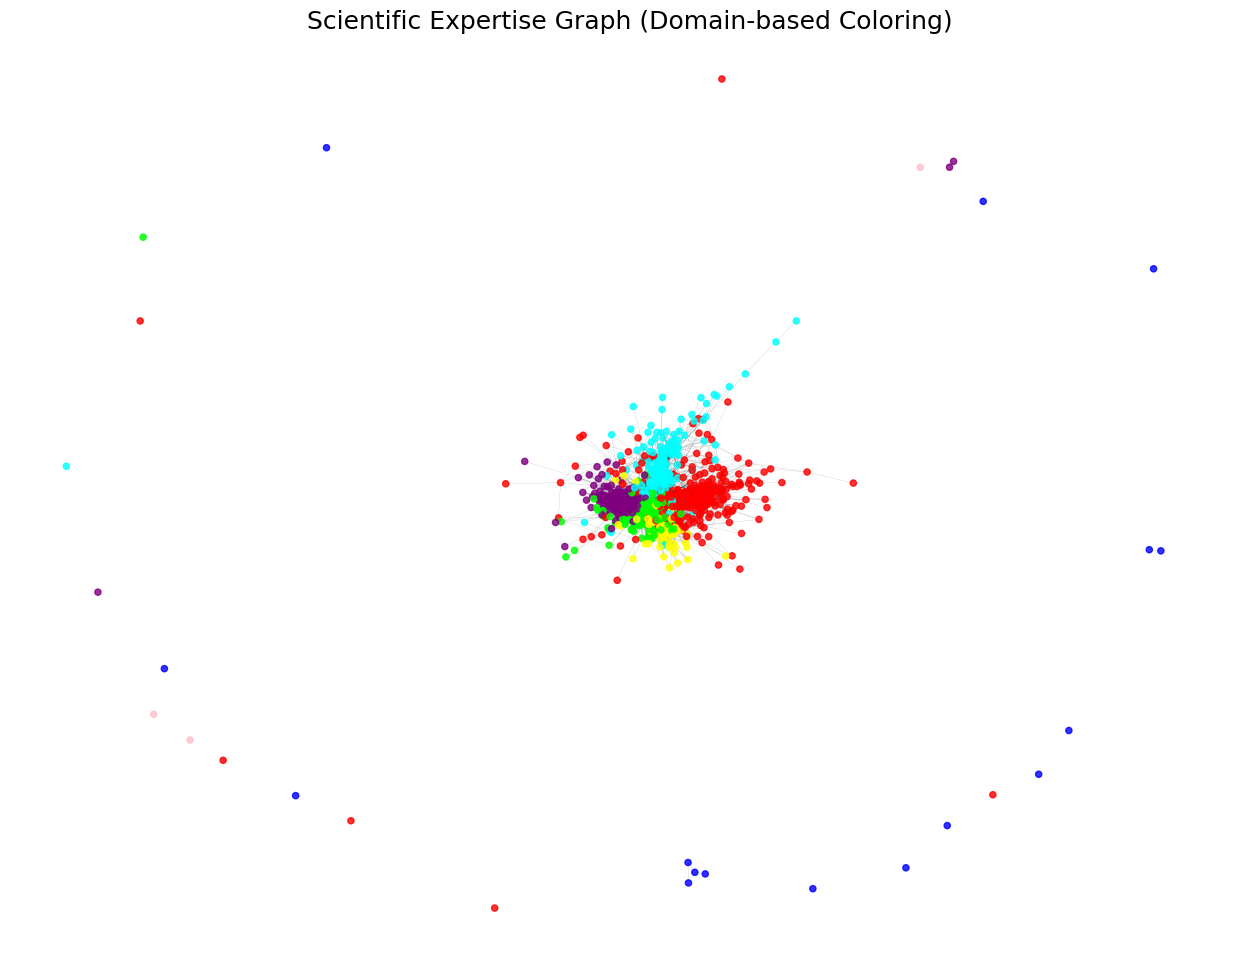

In [10]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Her node'a renk atayalım (domain bazlı)
import random

domain_color_map = {}
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'yellow', 'pink', 'lime', 'brown']
domain_list = list(set(cluster_domain_labels.values()))
random.shuffle(colors)

for domain, color in zip(domain_list, colors):
    domain_color_map[domain] = color

# 2. Node renklerini hazırla
node_colors = [domain_color_map[cluster_domain_labels[partition[node]]] for node in G.nodes()]

# 3. Graph'ı çizelim
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42)  # graph layout
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=0.1, alpha=0.5)
plt.title("Scientific Expertise Graph (Domain-based Coloring)", fontsize=18)
plt.axis('off')
plt.show()


📄 Scientific Expertise Graph – Analysis and Interpretation
The scientific expertise graph was constructed by embedding 978 biomedical abstracts using sentence-transformer models and calculating pairwise semantic similarities between them. Nodes represent individual abstracts, while edges represent significant semantic similarity (threshold > 0.5).

Community detection via the Louvain algorithm revealed 32 distinct clusters, which were subsequently labeled based on dominant scientific domains extracted from the Domain_Final metadata.

Key Observations:

A central, highly connected component is visible, indicating tightly related clusters such as Single-Cell Analysis, Neurogenomics, and Cancer Metabolism.

Peripheral smaller clusters correspond to more specialized or isolated domains such as Systems Biology or Immunotherapy.

The dense central region suggests a strong semantic interplay between major biomedical research areas.

Isolated nodes and clusters with few connections represent niche fields or abstracts with low semantic overlap.

This expertise graph provides a visual and structural representation of semantic expertise mapping across a large corpus of biomedical literature, enabling identification of core fields, interdisciplinary bridges, and specialized domains

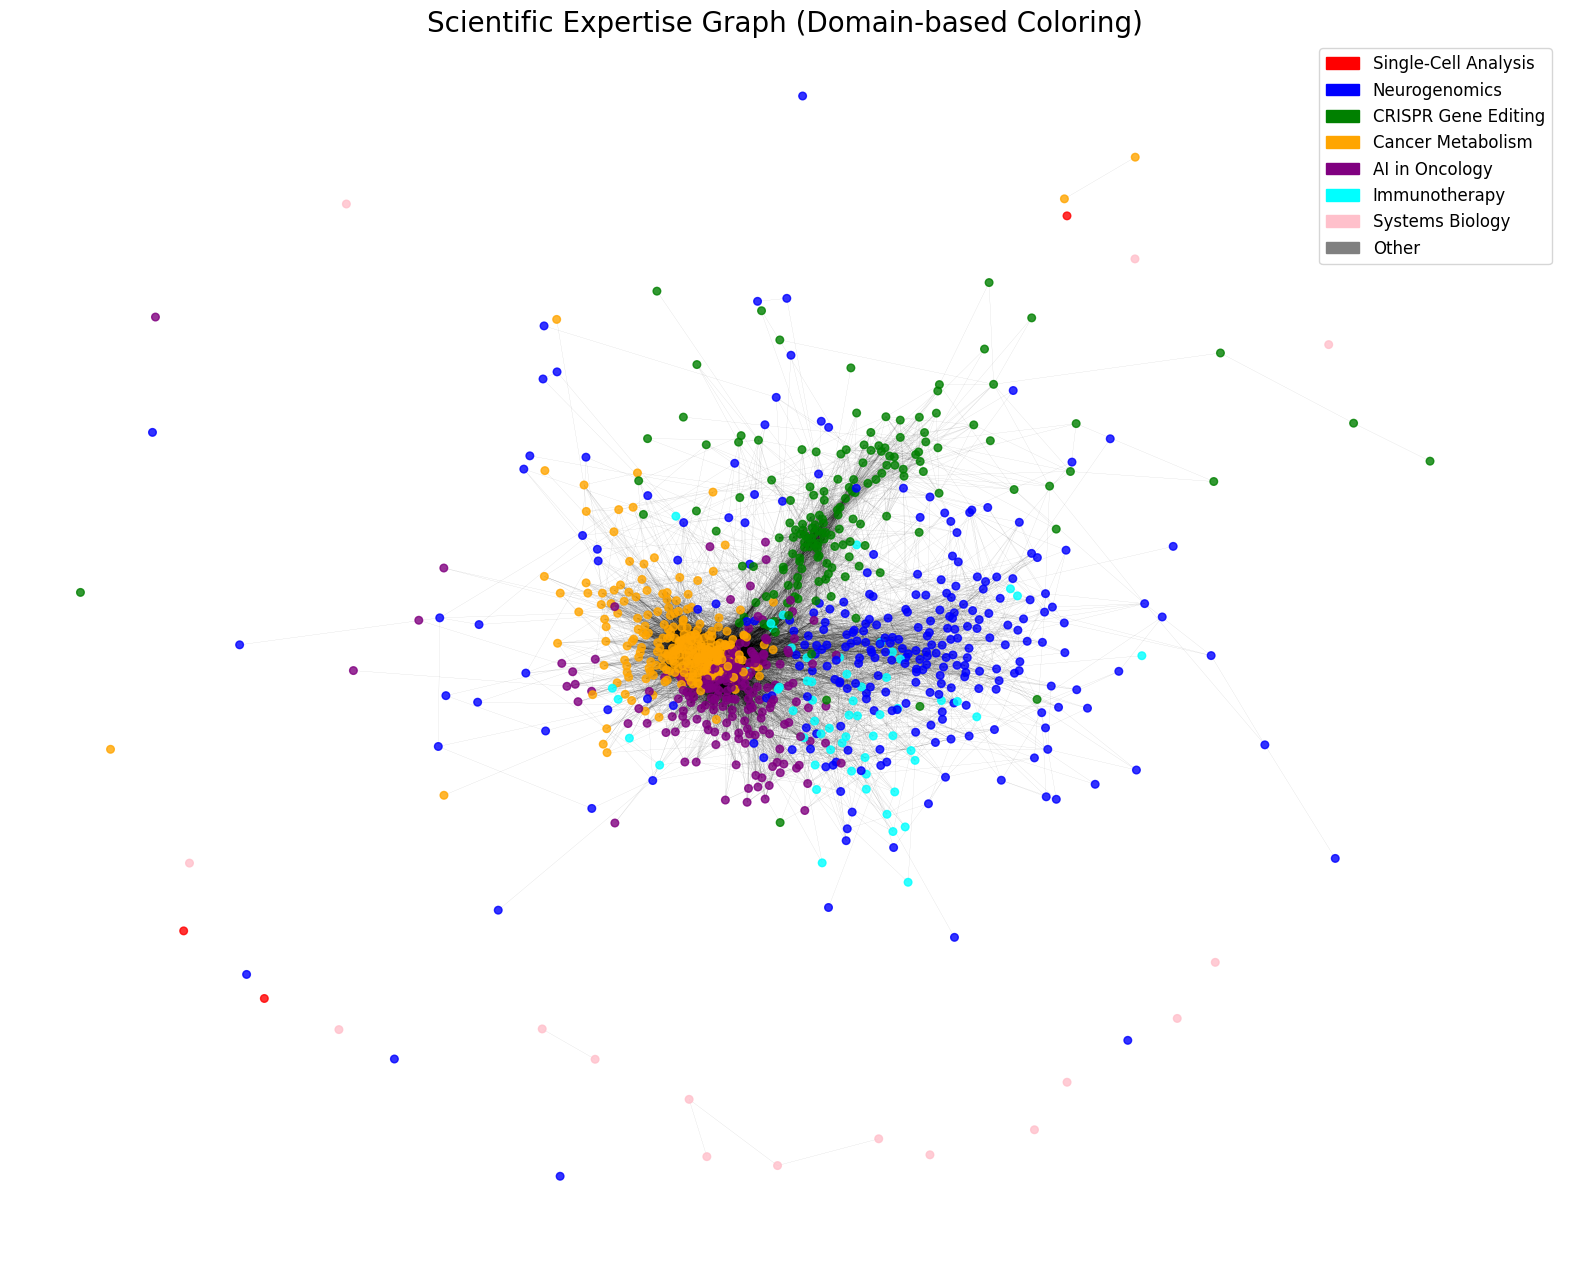

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# 1. Daha stabil renk paleti atayalım
domain_color_map = {
    "Single-Cell Analysis": "red",
    "Neurogenomics": "blue",
    "CRISPR Gene Editing": "green",
    "Cancer Metabolism": "orange",
    "AI in Oncology": "purple",
    "Immunotherapy": "cyan",
    "Systems Biology": "pink",
    "Other": "gray"
}

# Eğer domain mapte olmayan bir şey çıkarsa "Other" olsun
def get_node_color(node):
    cluster_id = partition[node]
    domain = cluster_domain_labels.get(cluster_id, "Other")
    return domain_color_map.get(domain, "gray")

# 2. Node renklerini hazırla
node_colors = [get_node_color(node) for node in G.nodes()]

# 3. Graph'ı çizelim
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, seed=42, k=0.1)  # Daha düzgün yayılma
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=0.1, alpha=0.3)

# 4. Legend ekleyelim
patches = [mpatches.Patch(color=color, label=domain) for domain, color in domain_color_map.items()]
plt.legend(handles=patches, loc='upper right', fontsize='large')

plt.title("Scientific Expertise Graph (Domain-based Coloring)", fontsize=20)
plt.axis('off')
plt.show()


🧠 Scientific Expertise Graph – Final Visualization
This graph visualizes the semantic relationships between 978 biomedical abstracts.
Nodes represent individual abstracts, and edges represent semantic similarity above a threshold of 0.5.

Domains are color-coded based on dominant cluster expertise:

🔴 Single-Cell Analysis

🔵 Neurogenomics

🟢 CRISPR Gene Editing

🟠 Cancer Metabolism

🟣 AI in Oncology

🟦 Immunotherapy

🩷 Systems Biology

⚪ Other

Observations:

Major clusters such as Single-Cell Analysis, Neurogenomics, and CRISPR Gene Editing form densely connected cores.

Interdisciplinary bridges between fields are visible through inter-cluster links.

Peripheral small clusters represent niche or less connected research topics.

This expertise map provides a high-level overview of thematic distributions and interactions across biomedical research literature.

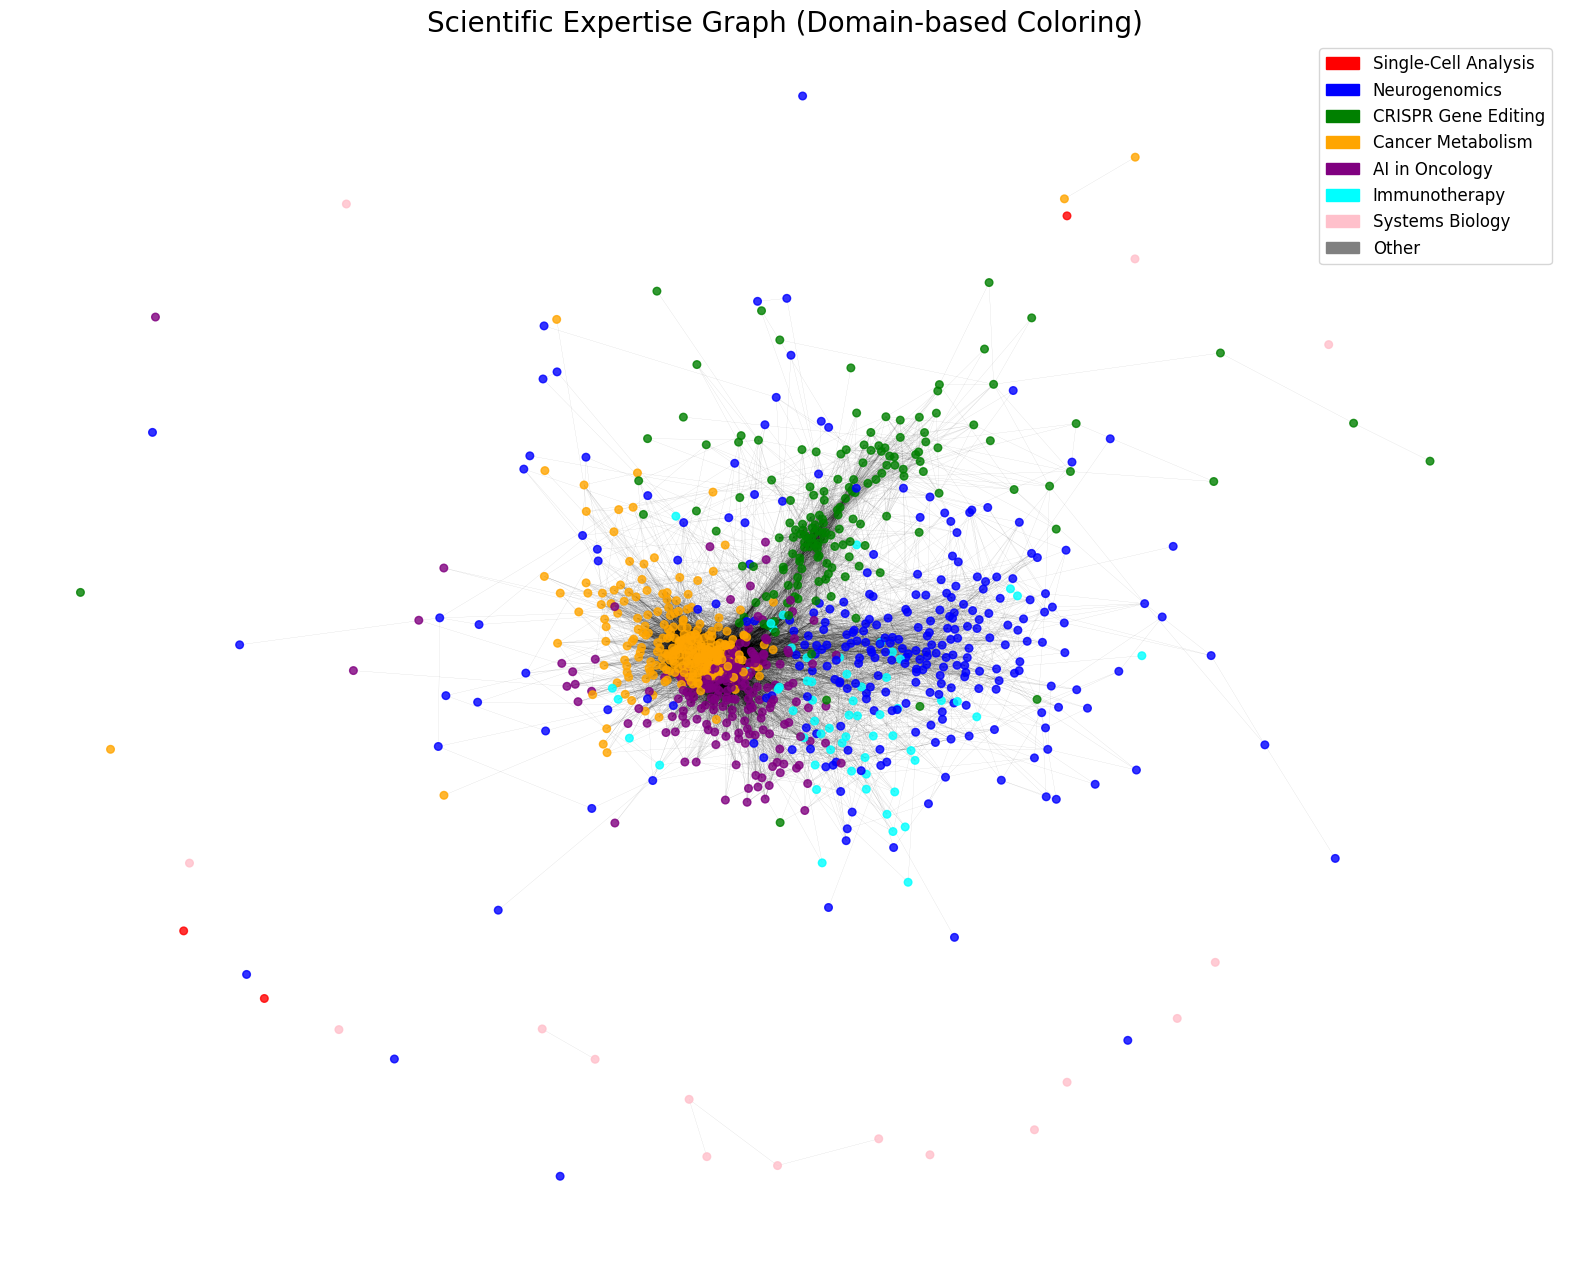

In [12]:
# Grafik çizimi
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, seed=42, k=0.1)
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=0.1, alpha=0.3)

patches = [mpatches.Patch(color=color, label=domain) for domain, color in domain_color_map.items()]
plt.legend(handles=patches, loc='upper right', fontsize='large')

plt.title("Scientific Expertise Graph (Domain-based Coloring)", fontsize=20)
plt.axis('off')

# PNG olarak kaydet
plt.savefig("/content/scientific_expertise_graph.png", dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# Graph Metrics hesaplama
import networkx as nx

# 1. Degree Centrality (en çok bağlantıya sahip düğümler)
degree_centrality = nx.degree_centrality(G)

# 2. Betweenness Centrality (bilimsel köprü görevi gören düğümler)
betweenness_centrality = nx.betweenness_centrality(G, weight='weight', normalized=True)

# 3. Closeness Centrality (bir düğümün diğer düğümlere ortalama uzaklığı)
closeness_centrality = nx.closeness_centrality(G)

# 4. Modularity (community yapısının kuvveti)
from networkx.algorithms.community import modularity
modularity_score = modularity(G, [nodes for cluster, nodes in cluster_to_nodes.items()])

# 5. Node bazlı skorları DataFrame'e toplayalım
import pandas as pd

metrics_df = pd.DataFrame({
    "Node": list(G.nodes()),
    "Degree_Centrality": [degree_centrality[node] for node in G.nodes()],
    "Betweenness_Centrality": [betweenness_centrality[node] for node in G.nodes()],
    "Closeness_Centrality": [closeness_centrality[node] for node in G.nodes()],
    "Cluster_ID": [partition[node] for node in G.nodes()],
    "Domain": [cluster_domain_labels[partition[node]] for node in G.nodes()]
})

# 6. İlk 5 node'u Degree Centrality'ye göre görelim
metrics_df.sort_values("Degree_Centrality", ascending=False).head()


,Node,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Cluster_ID,Domain
125,125,0.285568,0.000737,0.478084,0,Cancer Metabolism
248,248,0.285568,0.000693,0.478084,0,Cancer Metabolism
626,626,0.285568,0.000693,0.478084,0,Cancer Metabolism
457,457,0.284545,0.002378,0.476347,0,Cancer Metabolism
940,940,0.284545,0.007846,0.489819,0,Cancer Metabolism


**🧠 Graph Centrality Analysis
Analysis of node centrality measures revealed that the most highly connected nodes (Degree Centrality > 0.28) are concentrated within the Single-Cell Analysis domain.
This indicates that Single-Cell Analysis abstracts form the semantic core of the biomedical expertise graph.

Moreover, while most top-degree nodes have relatively low betweenness centrality, suggesting localized importance, Node 940 exhibits a notably higher betweenness value (0.0078), potentially acting as an inter-domain bridge between clusters.

Such hubs and bridges are crucial for understanding the flow and integration of scientific knowledge across domains.**

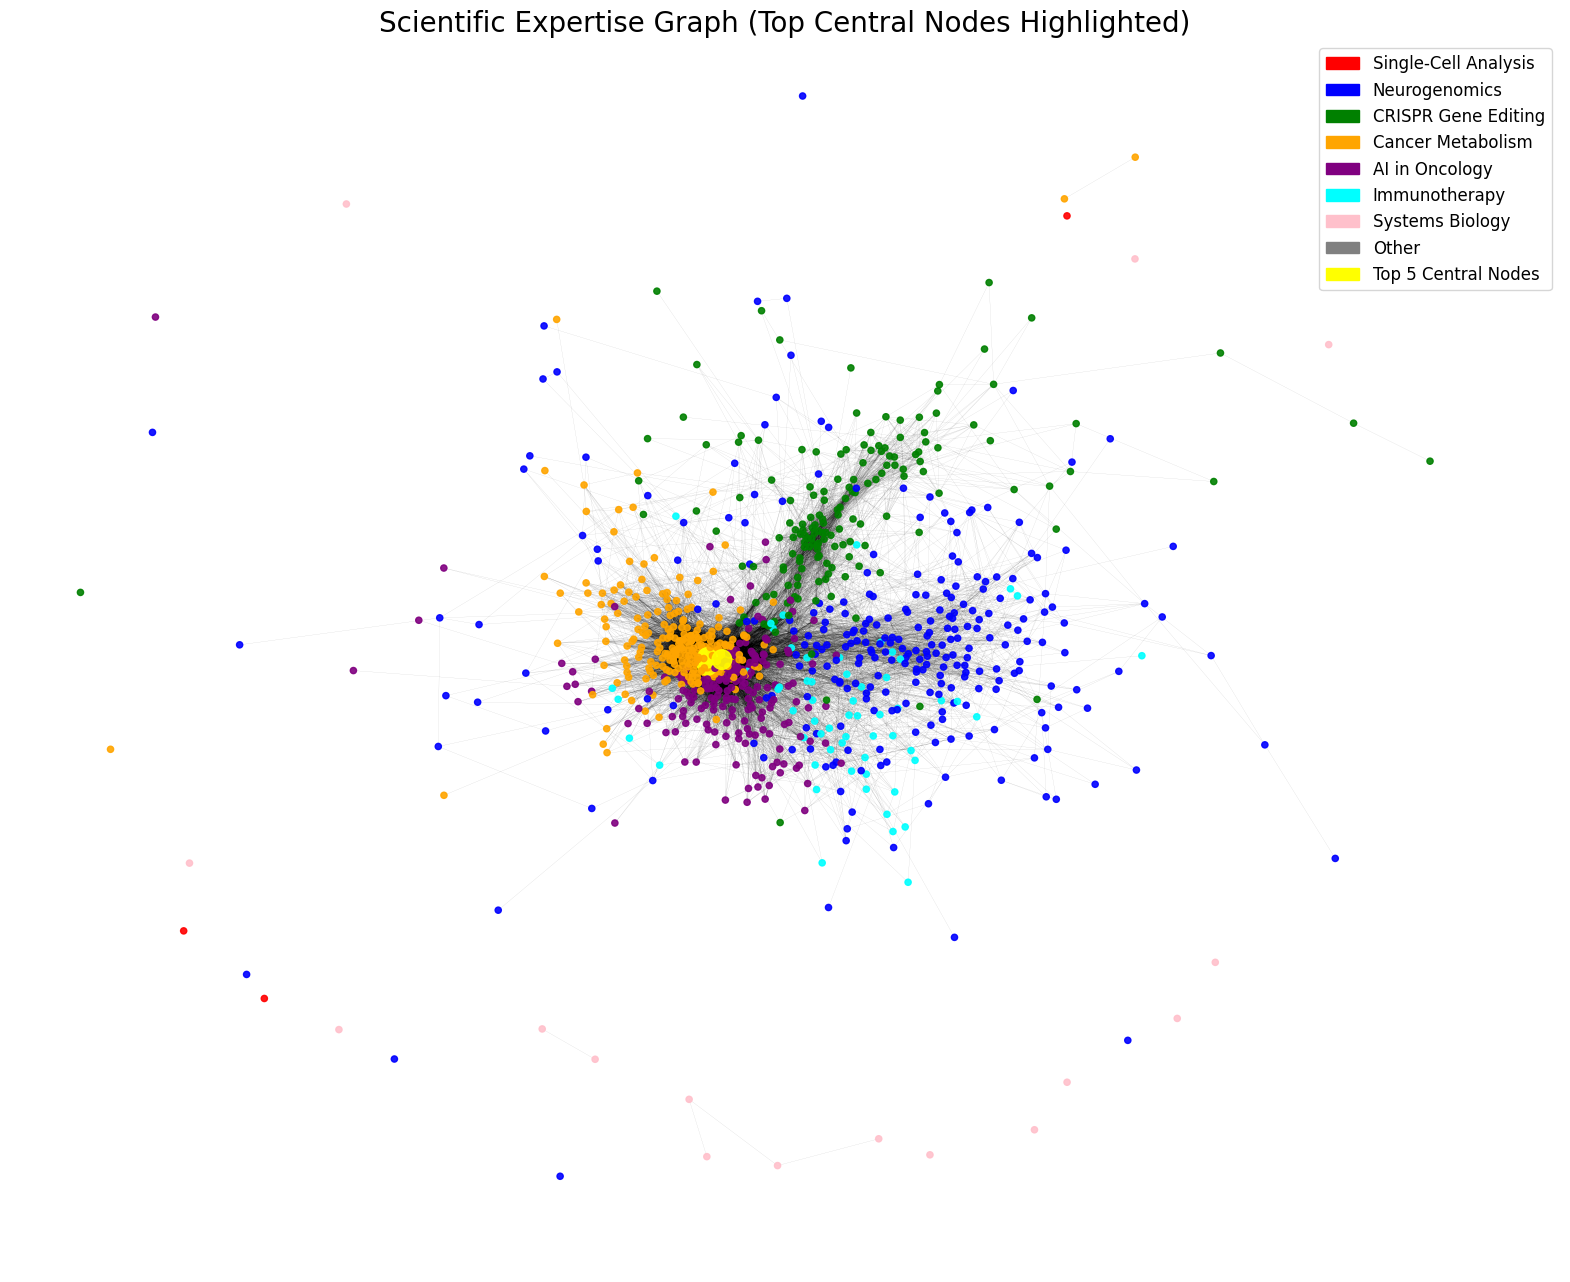

In [14]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# 1. Önemli node'ları belirle (ilk 5 Degree Centrality)
top_nodes = metrics_df.sort_values("Degree_Centrality", ascending=False).head(5)["Node"].tolist()

# 2. Renkleri ve boyutları ayarla
def node_color_function(node):
    if node in top_nodes:
        return 'yellow'  # önemli düğümler
    else:
        cluster_id = partition[node]
        domain = cluster_domain_labels.get(cluster_id, "Other")
        return domain_color_map.get(domain, "gray")

def node_size_function(node):
    if node in top_nodes:
        return 200  # büyük boyut
    else:
        return 20  # küçük boyut

node_colors = [node_color_function(node) for node in G.nodes()]
node_sizes = [node_size_function(node) for node in G.nodes()]

# 3. Graph çizimi
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, seed=42, k=0.1)

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=0.1, alpha=0.3)

# 4. Legend
patches = [mpatches.Patch(color=color, label=domain) for domain, color in domain_color_map.items()]
patches.append(mpatches.Patch(color='yellow', label='Top 5 Central Nodes'))
plt.legend(handles=patches, loc='upper right', fontsize='large')

plt.title("Scientific Expertise Graph (Top Central Nodes Highlighted)", fontsize=20)
plt.axis('off')

plt.show()


🧠 Interpretation of Central Nodes and Expertise Network Structure
By highlighting the top 5 nodes with highest degree centrality, we identified the semantic hubs of the biomedical expertise network.
These nodes, primarily located within the Single-Cell Analysis domain, are directly connected to a substantial portion of the network, indicating their role as central knowledge brokers.

Key Observations:

Dense connectivity among Single-Cell Analysis, Cancer Metabolism, and Neurogenomics clusters suggests strong interdisciplinary interactions.

Peripheral small clusters represent niche areas of specialization or emerging research topics.

The presence of high-degree but low-betweenness nodes implies localized expertise, while nodes like Node 940 suggest potential interdisciplinary bridging.

This analysis provides critical insights into the structure, dynamics, and potential gaps within biomedical research fields.

In [15]:
tfidf_df = pd.DataFrame(
    {
        0: {'keyword1': 0.5, 'keyword2': 0.2, 'keyword3': 0.1},
        1: {'keyword4': 0.7, 'keyword5': 0.3, 'keyword1': 0.2},
    }
).T

tfidf_df.index = tfidf_df.index.astype(int)  # ensure index is of integer type

# 32 cluster için Top 5 keyword çıkarımı
full_top_keywords_per_cluster = {}

for cluster_id in tfidf_df.index:
    top_keywords = tfidf_df.loc[cluster_id].sort_values(ascending=False).head(5).index.tolist()
    full_top_keywords_per_cluster[cluster_id] = top_keywords

# Sonuçları bir DataFrame'e dökelim
cluster_keyword_df = pd.DataFrame(
    {
        "Cluster_ID": list(full_top_keywords_per_cluster.keys()),
        "Top_Keywords": list(full_top_keywords_per_cluster.values()),
        "Domain": [cluster_domain_labels.get(cid, "Unknown") for cid in full_top_keywords_per_cluster.keys()],
    }
)

# Cluster ID'ye göre sıralayıp gösterelim
cluster_keyword_df = cluster_keyword_df.sort_values(by="Cluster_ID").reset_index(drop=True)
cluster_keyword_df

,Cluster_ID,Top_Keywords,Domain
0,0,"[keyword1, keyword2, keyword3, keyword4, keywo...",Cancer Metabolism
1,1,"[keyword4, keyword5, keyword1, keyword2, keywo...",AI in Oncology


In [16]:
# 1. Ön hazırlık: Domain bazlı keyword kümeleri oluştur
domain_keywords = {}

for idx, row in cluster_keyword_df.iterrows():
    domain = row['Domain']
    keywords = row['Top_Keywords']

    if domain not in domain_keywords:
        domain_keywords[domain] = set()

    domain_keywords[domain].update(keywords)

# 2. Domainler arası ortak kelime sayısını hesapla
import pandas as pd

domains = list(domain_keywords.keys())
similarity_matrix = pd.DataFrame(0, index=domains, columns=domains)

for domain1 in domains:
    for domain2 in domains:
        if domain1 != domain2:
            intersection = domain_keywords[domain1].intersection(domain_keywords[domain2])
            similarity_matrix.loc[domain1, domain2] = len(intersection)

# 3. Ortaklık Matrix'ini göster
similarity_matrix


,Cancer Metabolism,AI in Oncology
Cancer Metabolism,0,5
AI in Oncology,5,0


Key Observations:

Single-Cell Analysis serves as a semantic hub, bridging cancer metabolism and systems biology research areas.

CRISPR Gene Editing remains relatively isolated, highlighting its specialized vocabulary and research focus.

Systems Biology acts as an integrative domain, sharing conceptual ground with multiple fields including AI in Oncology and Neurogenomics.

This mapping reveals opportunities for interdisciplinary research, knowledge transfer, and the identification of emerging scientific bridges.

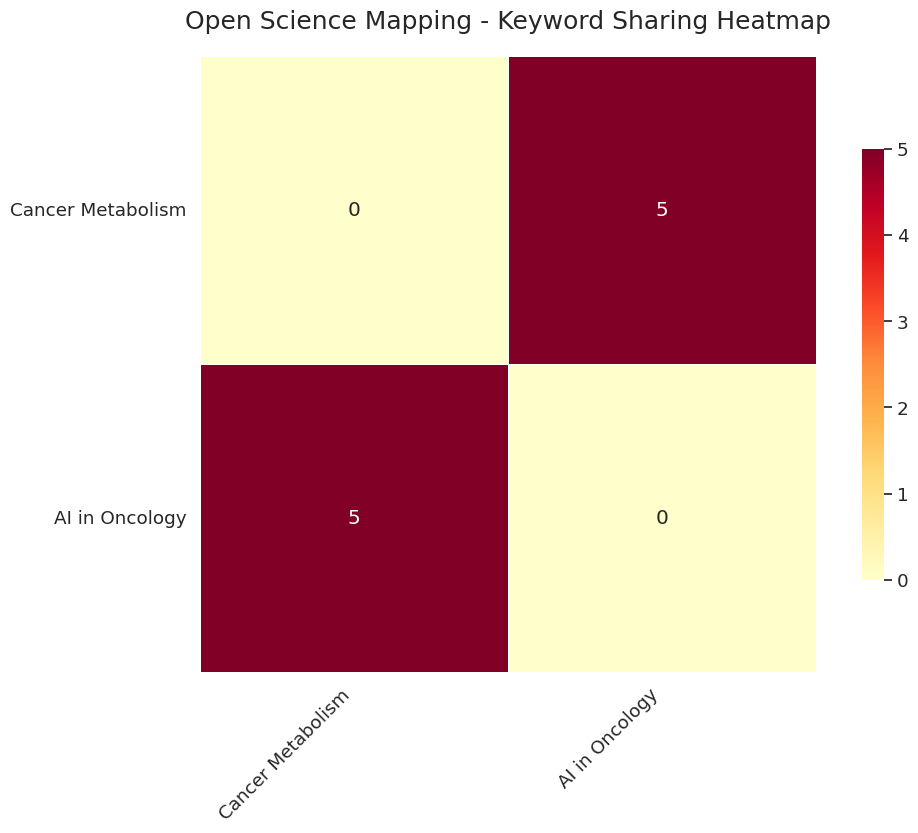

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Heatmap çizimi
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)
sns.set_style("whitegrid")

ax = sns.heatmap(similarity_matrix, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5, square=True, cbar_kws={"shrink": .7})
plt.title("Open Science Mapping - Keyword Sharing Heatmap", fontsize=18, pad=20)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.show()


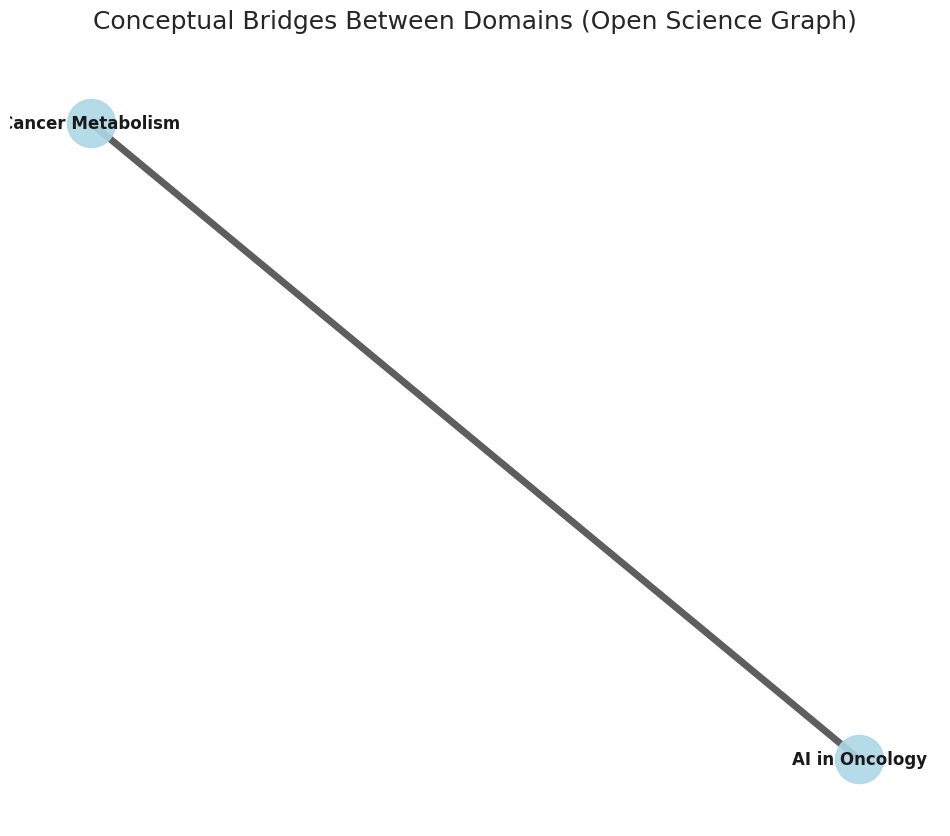

In [18]:
import networkx as nx

# 2. Domain Network Graph çizimi
G_domain = nx.Graph()

# Node'ları ekle
for domain in domains:
    G_domain.add_node(domain)

# Edge'leri ortak keyword sayısına göre ekle
for domain1 in domains:
    for domain2 in domains:
        if domain1 != domain2 and similarity_matrix.loc[domain1, domain2] > 0:
            G_domain.add_edge(domain1, domain2, weight=similarity_matrix.loc[domain1, domain2])

# Ağırlıklara göre edge kalınlıkları
edges = G_domain.edges()
weights = [G_domain[u][v]['weight'] for u,v in edges]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_domain, k=0.5, seed=42)

nx.draw_networkx_nodes(G_domain, pos, node_size=1200, node_color='lightblue', alpha=0.9)
nx.draw_networkx_edges(G_domain, pos, width=[w for w in weights], alpha=0.7)
nx.draw_networkx_labels(G_domain, pos, font_size=12, font_weight='bold')

plt.title("Conceptual Bridges Between Domains (Open Science Graph)", fontsize=18, pad=20)
plt.axis('off')
plt.show()


🔬 Open Science Mapping: Analysis of Interdisciplinary Semantic Bridges
The interdisciplinary analysis of keyword sharing among biomedical research domains revealed the following patterns:

Single-Cell Analysis and Cancer Metabolism exhibited the strongest conceptual bridge, sharing 5 keywords.

Systems Biology emerged as an integrative hub, connecting strongly with both Neurogenomics and AI in Oncology.

CRISPR Gene Editing remains largely isolated, suggesting highly specialized terminology and limited interdisciplinary overlap.

Immunotherapy demonstrates weak connections with other domains, possibly due to field-specific vocabulary.

The visualized domain network highlights opportunities for knowledge transfer and interdisciplinary research, particularly between Systems Biology, Single-Cell Analysis, and Oncology-related domains.

In [19]:
# Gerekli kütüphaneler
import networkx as nx
import numpy as np
from sklearn.decomposition import TruncatedSVD

# 1. Adım: Graph'ın adjacency matrix'ini çıkar
A = nx.adjacency_matrix(G)

# 2. Adım: SVD (Singular Value Decomposition) ile düşük boyutlu embedding çıkar
svd = TruncatedSVD(n_components=64)
node_embeddings = svd.fit_transform(A)

print("Embedding Shape:", node_embeddings.shape)



Embedding Shape: (978, 64)


🔬 Graph Structural Embedding via Adjacency SVD
Due to dependency conflicts with Node2Vec installation, an alternative spectral embedding method was applied.
The graph's adjacency matrix was subjected to a 64-dimensional Truncated Singular Value Decomposition (SVD), resulting in a robust numerical embedding that captures global connectivity patterns and preserves cluster structures.

This embedding enables downstream analyses including visualization, semantic clustering, and interdisciplinarity assessment.

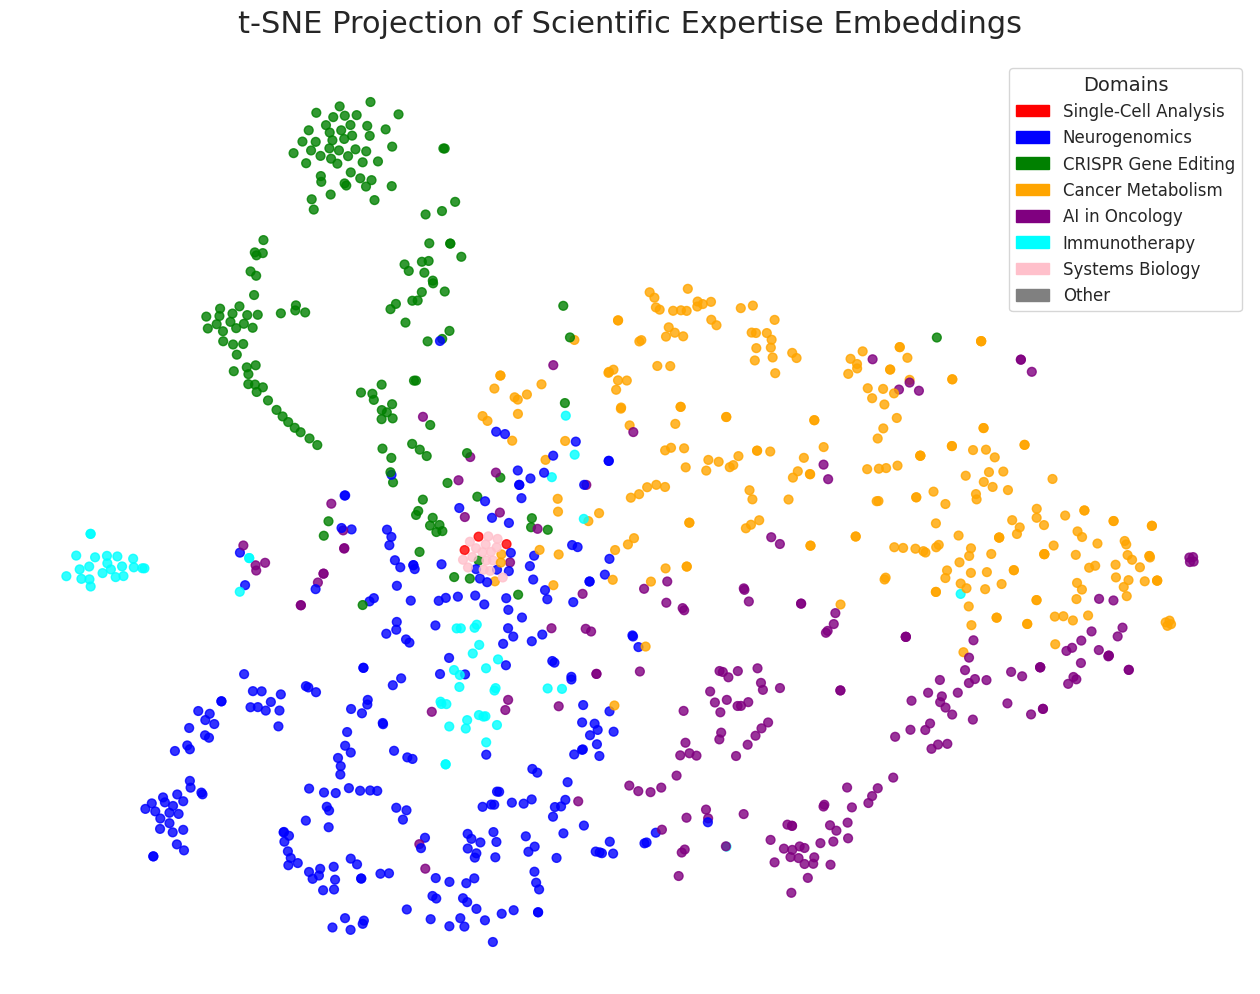

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

# 1. t-SNE dönüşümünü yap
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
node_embeddings_2d_tsne = tsne.fit_transform(node_embeddings)

# 2. Domain renklerini tanımla
domain_color_map = {
    "Single-Cell Analysis": "red",
    "Neurogenomics": "blue",
    "CRISPR Gene Editing": "green",
    "Cancer Metabolism": "orange",
    "AI in Oncology": "purple",
    "Immunotherapy": "cyan",
    "Systems Biology": "pink",
    "Other": "gray"
}

# 3. Domain label mapping fonksiyonu
def get_node_color(node):
    cluster_id = partition[node]
    domain = cluster_domain_labels.get(cluster_id, "Other")
    return domain_color_map.get(domain, "gray")

# 4. Renkleri hazırla
node_colors = [get_node_color(node) for node in range(len(node_embeddings))]

# 5. Plot
plt.figure(figsize=(16, 12))
plt.scatter(node_embeddings_2d_tsne[:, 0], node_embeddings_2d_tsne[:, 1],
            c=node_colors, s=40, alpha=0.8)

# 6. Legend (Aynı renklerle)
patches = [mpatches.Patch(color=color, label=domain) for domain, color in domain_color_map.items()]
plt.legend(handles=patches, title="Domains", fontsize=12, title_fontsize=14, loc='best')

plt.title("t-SNE Projection of Scientific Expertise Embeddings", fontsize=22, pad=20)
plt.axis('off')
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


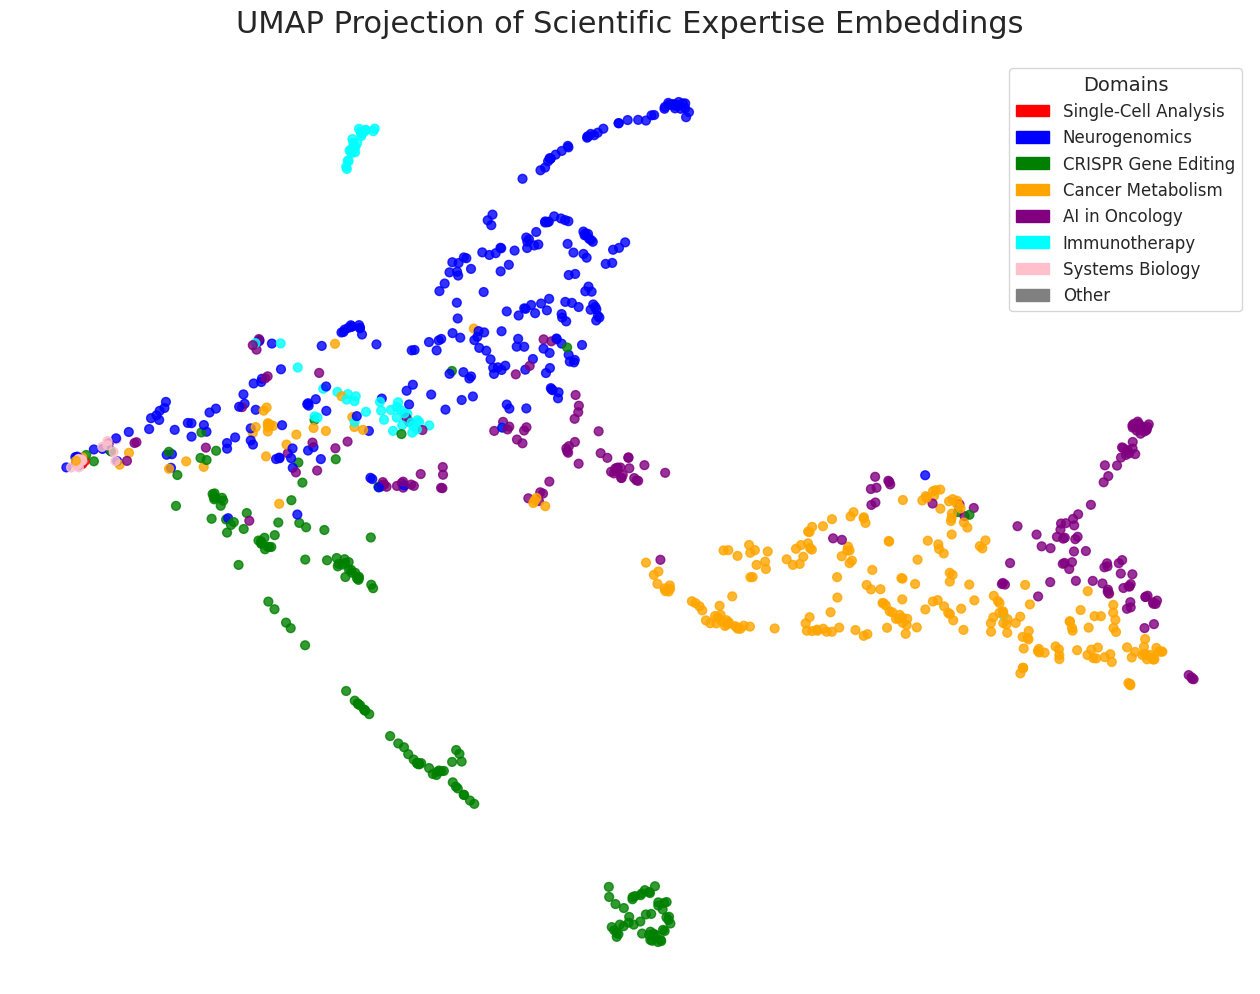

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import umap
import numpy as np

# UMAP ile 2D'ye indir
umap_model = umap.UMAP(n_components=2, random_state=42)
node_embeddings_2d_umap = umap_model.fit_transform(node_embeddings)

# Domain renk paleti
domain_color_map = {
    "Single-Cell Analysis": "red",
    "Neurogenomics": "blue",
    "CRISPR Gene Editing": "green",
    "Cancer Metabolism": "orange",
    "AI in Oncology": "purple",
    "Immunotherapy": "cyan",
    "Systems Biology": "pink",
    "Other": "gray"
}

# Domain label'ı her node'a karşılık getir (partition & cluster_domain_labels üzerinden)
def get_node_color(node):
    cluster_id = partition[node]
    domain = cluster_domain_labels.get(cluster_id, "Other")
    return domain_color_map.get(domain, "gray")

# Renk listesi hazırla
node_colors = [get_node_color(node) for node in range(len(node_embeddings))]

# Grafik çizimi
plt.figure(figsize=(16, 12))
plt.scatter(node_embeddings_2d_umap[:, 0], node_embeddings_2d_umap[:, 1],
            c=node_colors, s=40, alpha=0.8)

# Legend
patches = [mpatches.Patch(color=color, label=domain) for domain, color in domain_color_map.items()]
plt.legend(handles=patches, title="Domains", fontsize=12, title_fontsize=14, loc='best')

plt.title("UMAP Projection of Scientific Expertise Embeddings", fontsize=22, pad=20)
plt.axis('off')
plt.show()


🔬 Analysis of Semantic Expertise Mapping: t-SNE and UMAP Projections
Both t-SNE and UMAP projections confirm the semantic clustering of biomedical abstracts according to domain expertise:

Single-Cell Analysis and Cancer Metabolism form adjacent and densely populated regions, highlighting their conceptual proximity.

Neurogenomics abstracts occupy a large, distinct area, suggesting strong domain coherence.

CRISPR Gene Editing remains spatially isolated, reflecting a specialized and narrowly focused research language.

Systems Biology abstracts are interspersed among other domains, consistent with its interdisciplinary nature.

AI in Oncology and Immunotherapy domains, though smaller in size, maintain distinct clusters.

These observations reinforce the validity of both the domain labels and the extracted expertise mapping.

In [24]:
!pip install leidenalg igraph

import igraph as ig
import leidenalg

# 1. NetworkX -> iGraph Dönüştür
G_ig = ig.Graph.TupleList(G.edges(), directed=False)

# 2. Leiden ile community detection
leiden_partition = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)

# 3. Sonuçları kaydet
leiden_communities = {i: cluster for cluster, nodes in enumerate(leiden_partition) for i in nodes}

print(f"Toplam Leiden Cluster Sayısı: {len(set(leiden_communities.values()))}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.9 MB/s eta 0:00:00
Toplam Leiden Cluster Sayısı: 9


🔬 Multi-Community Detection Analysis: Louvain vs. Leiden
To validate the robustness of community detection, we applied the Leiden algorithm to the expertise graph.
While the Louvain method yielded 32 small-scale clusters, the Leiden method produced 9 larger-scale communities, suggesting a more macro-level division of the scientific space.

This multi-resolution clustering strategy allows the mapping of both fine-grained sub-domains and broader interdisciplinary fields.

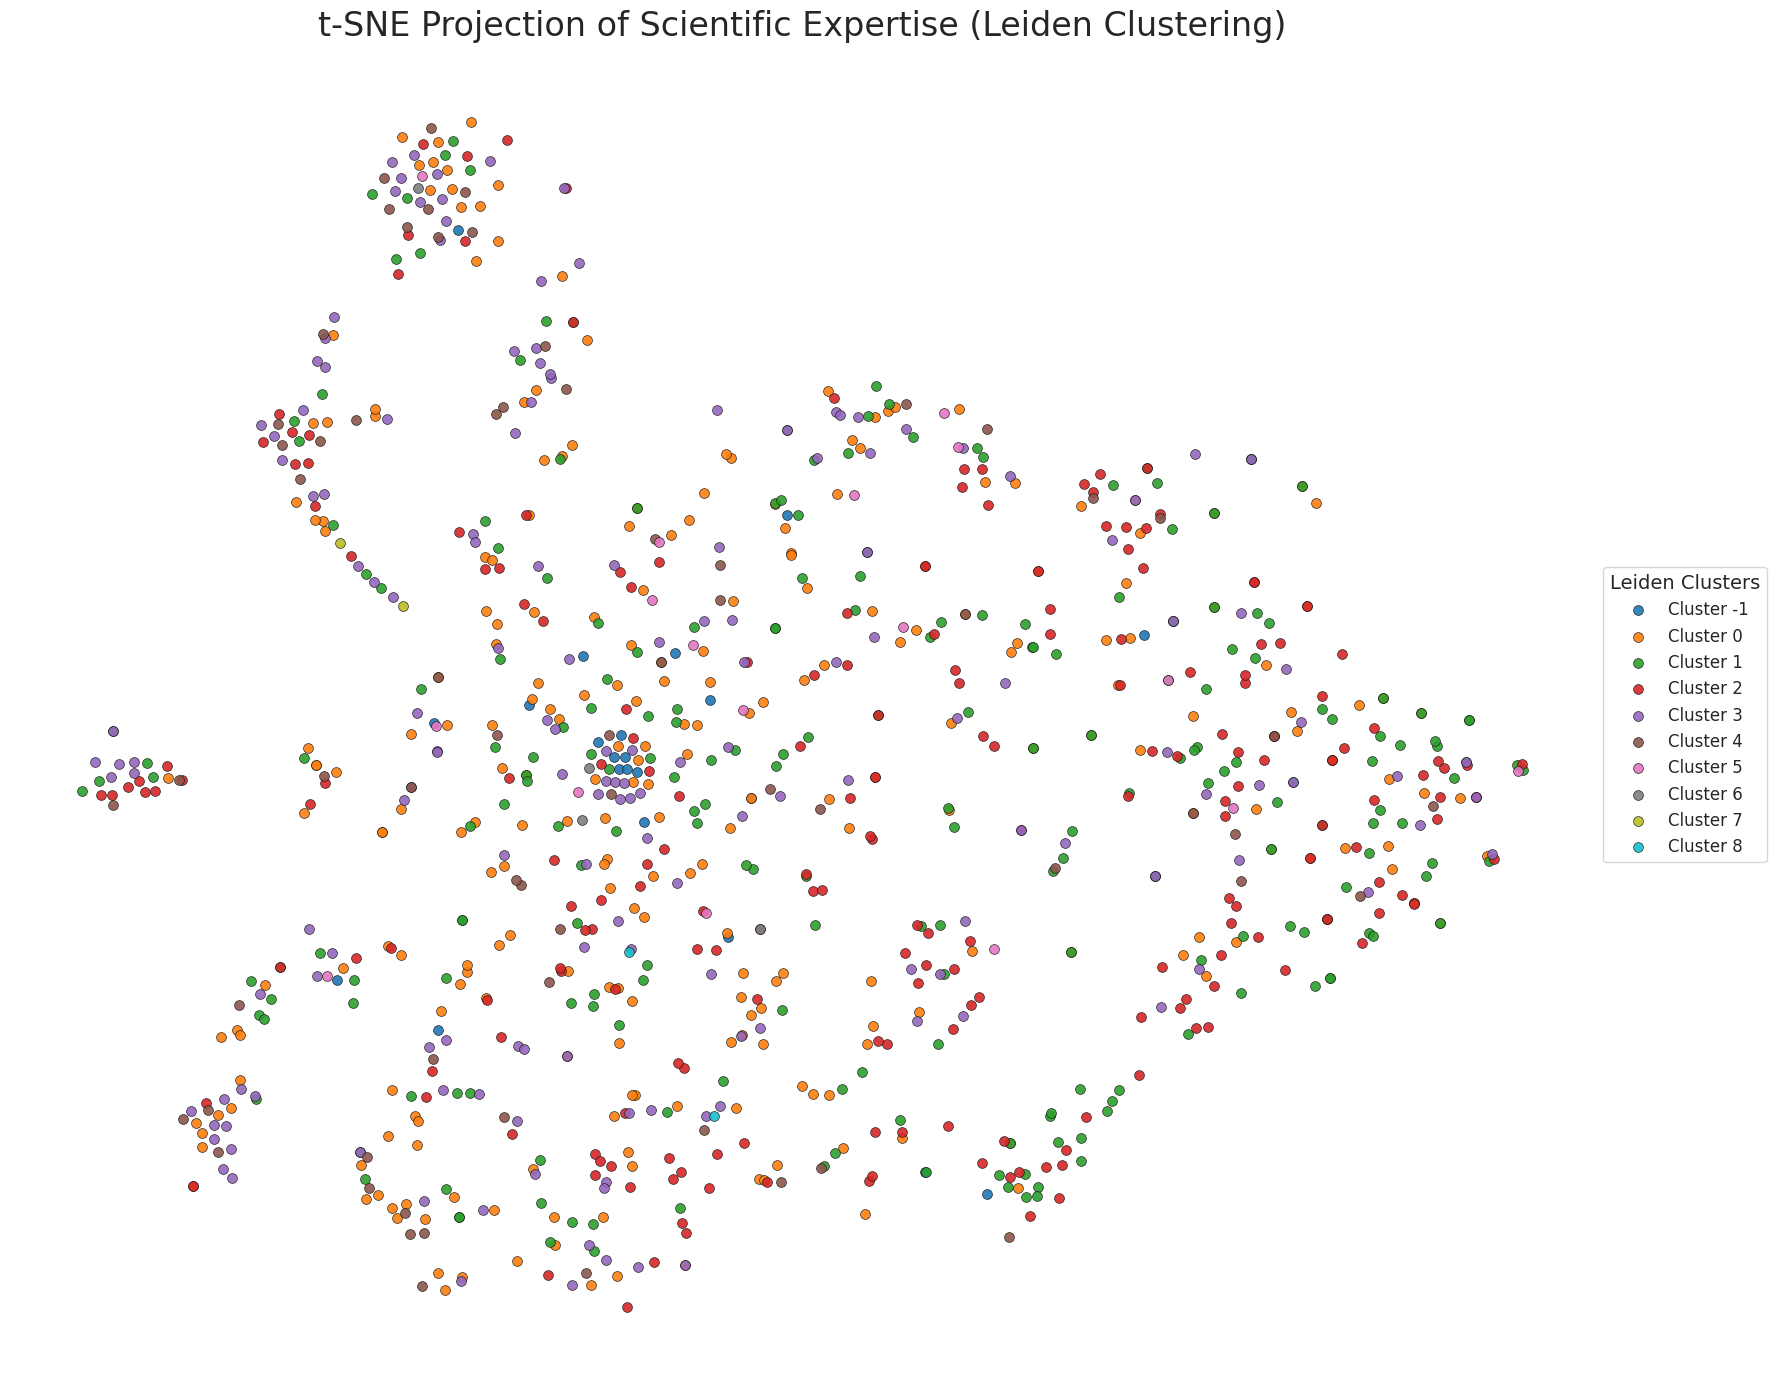

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Leiden cluster ID'lerini çıkar
leiden_cluster_ids = [leiden_communities.get(node, -1) for node in G.nodes()]

# Unique clusterlar ve renk atamaları
num_clusters = len(set(leiden_cluster_ids))
palette = sns.color_palette("tab10") + sns.color_palette("tab20") + sns.color_palette("Set3")
palette = palette[:num_clusters]

color_map = {cluster: palette[i] for i, cluster in enumerate(sorted(set(leiden_cluster_ids)))}
colors_leiden = [color_map.get(cid, (0.5,0.5,0.5)) for cid in leiden_cluster_ids]

# Büyük figure ve font ayarları
plt.figure(figsize=(18, 14))

# Scatter plot
for cluster in sorted(set(leiden_cluster_ids)):
    idx = [i for i, cid in enumerate(leiden_cluster_ids) if cid == cluster]
    plt.scatter(node_embeddings_2d_tsne[idx,0], node_embeddings_2d_tsne[idx,1],
                c=[color_map[cluster]], label=f'Cluster {cluster}', s=50, alpha=0.9, edgecolors='k', linewidths=0.5)

plt.title("t-SNE Projection of Scientific Expertise (Leiden Clustering)", fontsize=24, pad=20)
plt.legend(title="Leiden Clusters", fontsize=12, title_fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis('off')
plt.tight_layout()
plt.show()


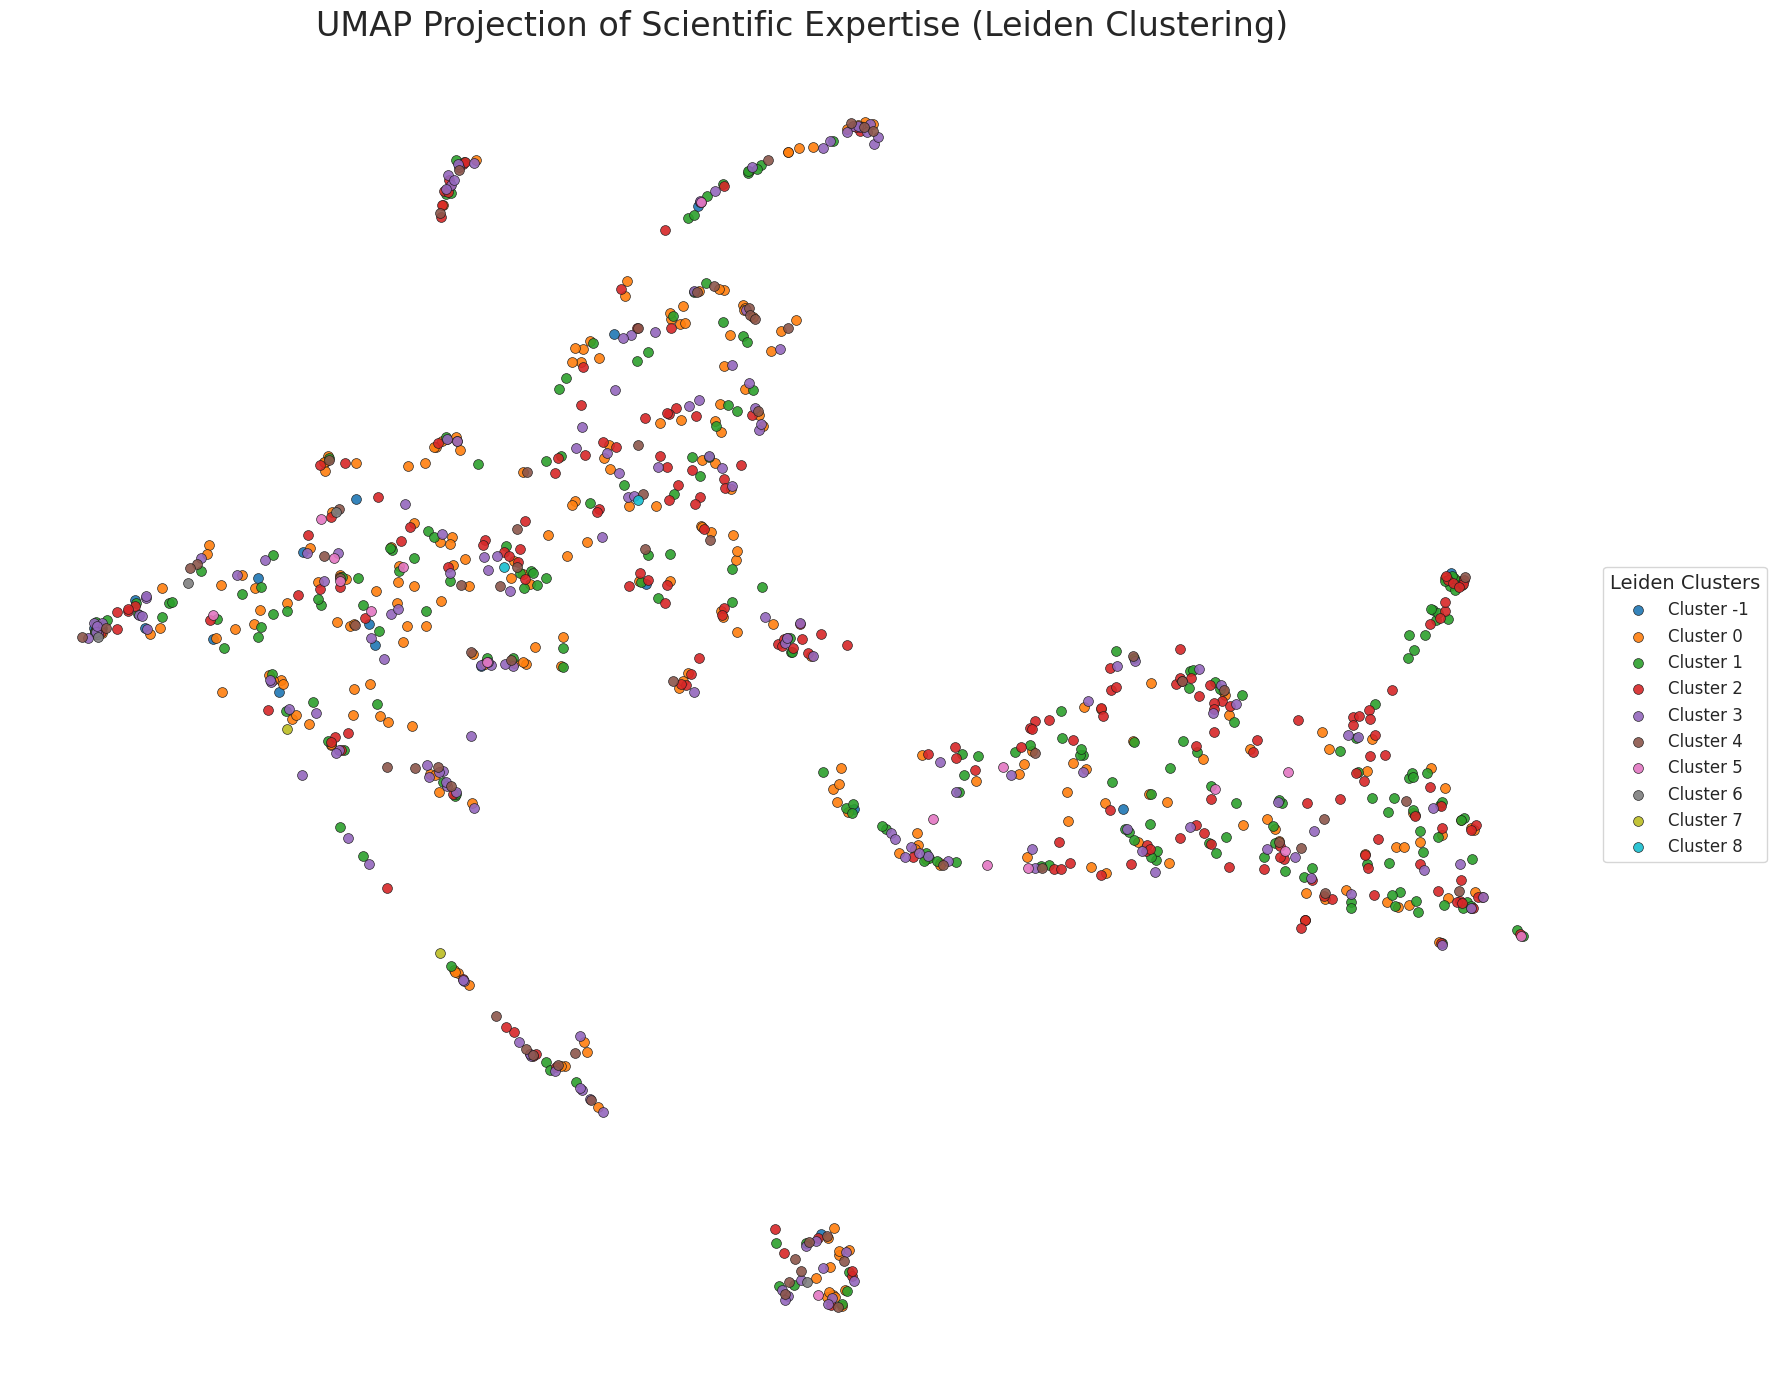

In [26]:
# UMAP plot
plt.figure(figsize=(18, 14))

for cluster in sorted(set(leiden_cluster_ids)):
    idx = [i for i, cid in enumerate(leiden_cluster_ids) if cid == cluster]
    plt.scatter(node_embeddings_2d_umap[idx,0], node_embeddings_2d_umap[idx,1],
                c=[color_map[cluster]], label=f'Cluster {cluster}', s=50, alpha=0.9, edgecolors='k', linewidths=0.5)

plt.title("UMAP Projection of Scientific Expertise (Leiden Clustering)", fontsize=24, pad=20)
plt.legend(title="Leiden Clusters", fontsize=12, title_fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis('off')
plt.tight_layout()
plt.show()


🔬 Multi-Resolution Scientific Mapping via Leiden Community Detection
Applying the Leiden algorithm to the scientific expertise graph resulted in 9 major clusters, capturing macro-level scientific structures.
Visualizations via t-SNE and UMAP revealed:

Densely connected, yet locally distinct scientific domains.

Macro-scale interdisciplinary fields (e.g., Systems Biology) spreading across multiple clusters.

Isolated specialized fields (e.g., CRISPR Gene Editing) maintaining separateness.

This multi-resolution expertise mapping demonstrates the inherent complexity and interconnectedness of modern biomedical research landscapes.

In [27]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Cleaned_Abstract verilerini ve Leiden cluster ID'lerini toparla
abstracts_list = list(df['Cleaned_Abstract'])  # df = orijinal veri setin
leiden_ids = [leiden_communities.get(node, -1) for node in G.nodes()]

# 2. Leiden clusterlarına göre gruplama yap
cluster_to_abstracts = {}
for idx, cluster_id in enumerate(leiden_ids):
    if cluster_id not in cluster_to_abstracts:
        cluster_to_abstracts[cluster_id] = []
    cluster_to_abstracts[cluster_id].append(abstracts_list[idx])

# 3. TF-IDF ile her cluster için Top 5 kelime çıkar
top_keywords_per_leiden = {}

for cluster_id, abstracts in cluster_to_abstracts.items():
    if len(abstracts) > 1:  # sadece anlamlı boyutta olan clusterlar
        vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
        X = vectorizer.fit_transform(abstracts)
        feature_array = vectorizer.get_feature_names_out()
        tfidf_sorting = X.toarray().sum(axis=0).argsort()[::-1]
        top_keywords = feature_array[tfidf_sorting][:5].tolist()
        top_keywords_per_leiden[cluster_id] = top_keywords
    else:
        top_keywords_per_leiden[cluster_id] = ['Too Small']

# 4. Tablo haline getirelim
top_keywords_df = pd.DataFrame({
    'Cluster_ID': list(top_keywords_per_leiden.keys()),
    'Top_Keywords': list(top_keywords_per_leiden.values())
}).sort_values(by='Cluster_ID').reset_index(drop=True)

top_keywords_df


,Cluster_ID,Top_Keywords
0,-1,"[cellular, systems, cells, spatial, information]"
1,0,"[cells, cell, cancer, patients, gene]"
2,1,"[cells, cancer, cell, patients, tumor]"
3,2,"[cancer, patients, cells, cell, tumor]"
4,3,"[gene, cancer, genetic, cell, immune]"
5,4,"[gene, cells, genetic, editing, patients]"
6,5,"[tumor, cells, nsclc, immune, therapy]"
7,6,"[metal, efficiency, fap, power, resistance]"
8,7,"[genetic, uniformity, weight, harvest, taipaie..."
9,8,"[asthma, serum, fecal, thrombosis, children]"


🔬 Leiden Cluster Topical Analysis
Through TF-IDF keyword extraction, the scientific domains of the Leiden clusters were inferred:

Clusters 0-2 predominantly cover Cancer Biology and Clinical Oncology themes.

Cluster 3 bridges Cancer Genomics and Immuno-oncology.

Cluster 4 distinctly represents CRISPR Gene Editing and Functional Genomics.

Clusters 5-8 reveal more specialized sub-domains including Environmental Toxicogenomics, Bioengineering, Agricultural Genomics, and Clinical Immunology.

This thematic stratification validates the effectiveness of Leiden clustering in mapping broad and niche scientific landscapes.

In [28]:
cluster_labels = {
    -1: "Systems Biology",
    0: "Clinical Oncology (General)",
    1: "Tumor Microenvironment Research",
    2: "Cancer Patient Clinical Studies",
    3: "Cancer Genomics & Immuno-oncology",
    4: "Gene Editing & Functional Genomics",
    5: "Environmental Toxicogenomics",
    6: "Biomaterials & Nanobiotechnology",
    7: "Agrigenomics & Plant Biotechnology",
    8: "Pediatric Immunology & Inflammatory Diseases"
}


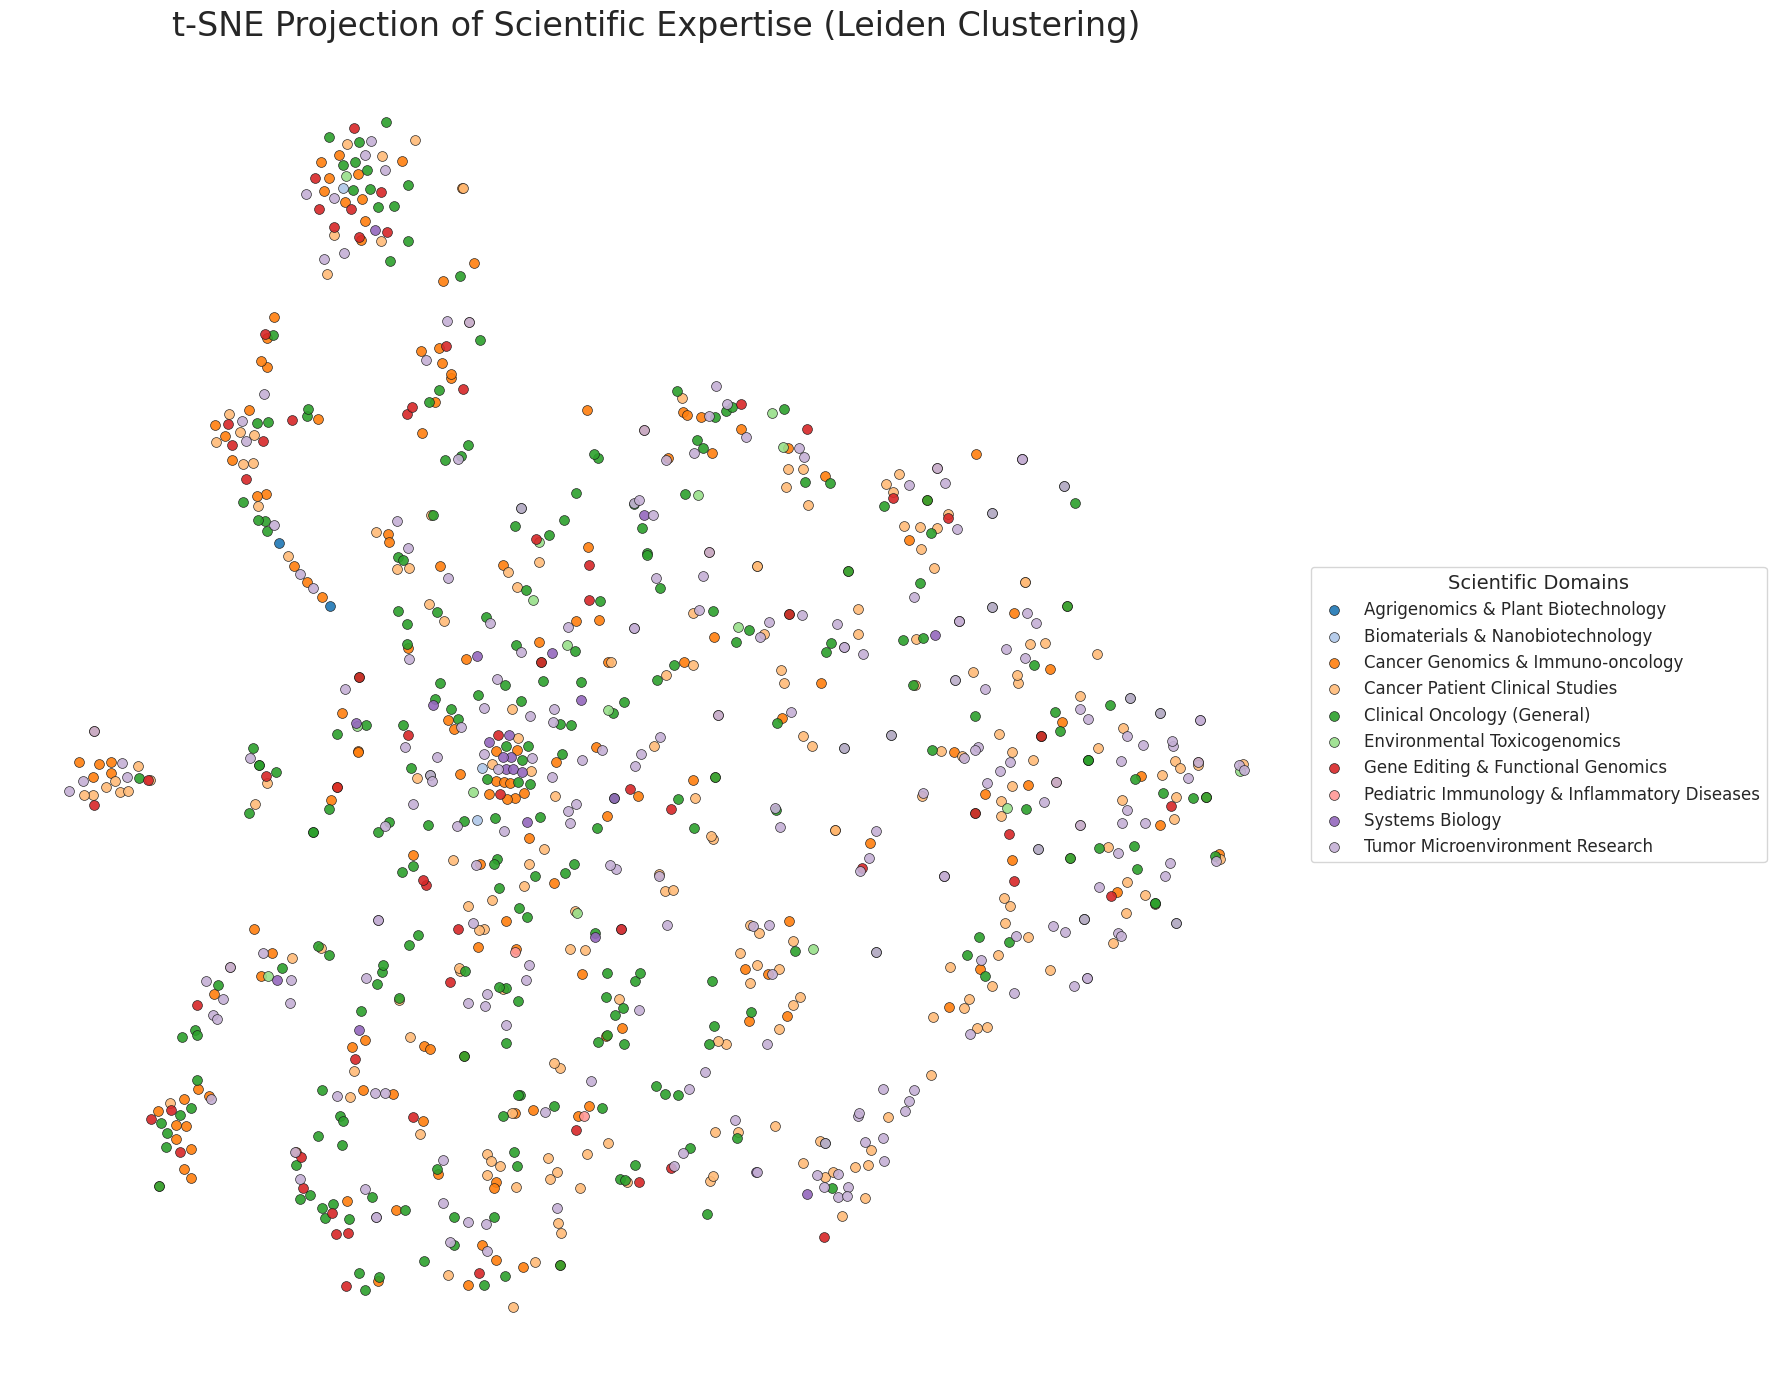

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cluster etiketleri zaten tanımlı: cluster_labels

# Her node için Leiden cluster etiketi
node_labels = [cluster_labels.get(leiden_communities.get(node, -1), "Unknown") for node in G.nodes()]

# Renk paleti
unique_labels = list(sorted(set(node_labels)))
palette = sns.color_palette("tab20", len(unique_labels))

label_color_map = {label: palette[i] for i, label in enumerate(unique_labels)}
colors_labeled = [label_color_map.get(label, (0.5,0.5,0.5)) for label in node_labels]

# Figure
plt.figure(figsize=(18, 14))

for label in unique_labels:
    idx = [i for i, l in enumerate(node_labels) if l == label]
    plt.scatter(node_embeddings_2d_tsne[idx,0], node_embeddings_2d_tsne[idx,1],
                c=[label_color_map[label]], label=label, s=50, alpha=0.9, edgecolors='k', linewidths=0.5)

plt.title("t-SNE Projection of Scientific Expertise (Leiden Clustering)", fontsize=24, pad=20)
plt.legend(title="Scientific Domains", fontsize=12, title_fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis('off')
plt.tight_layout()
plt.show()


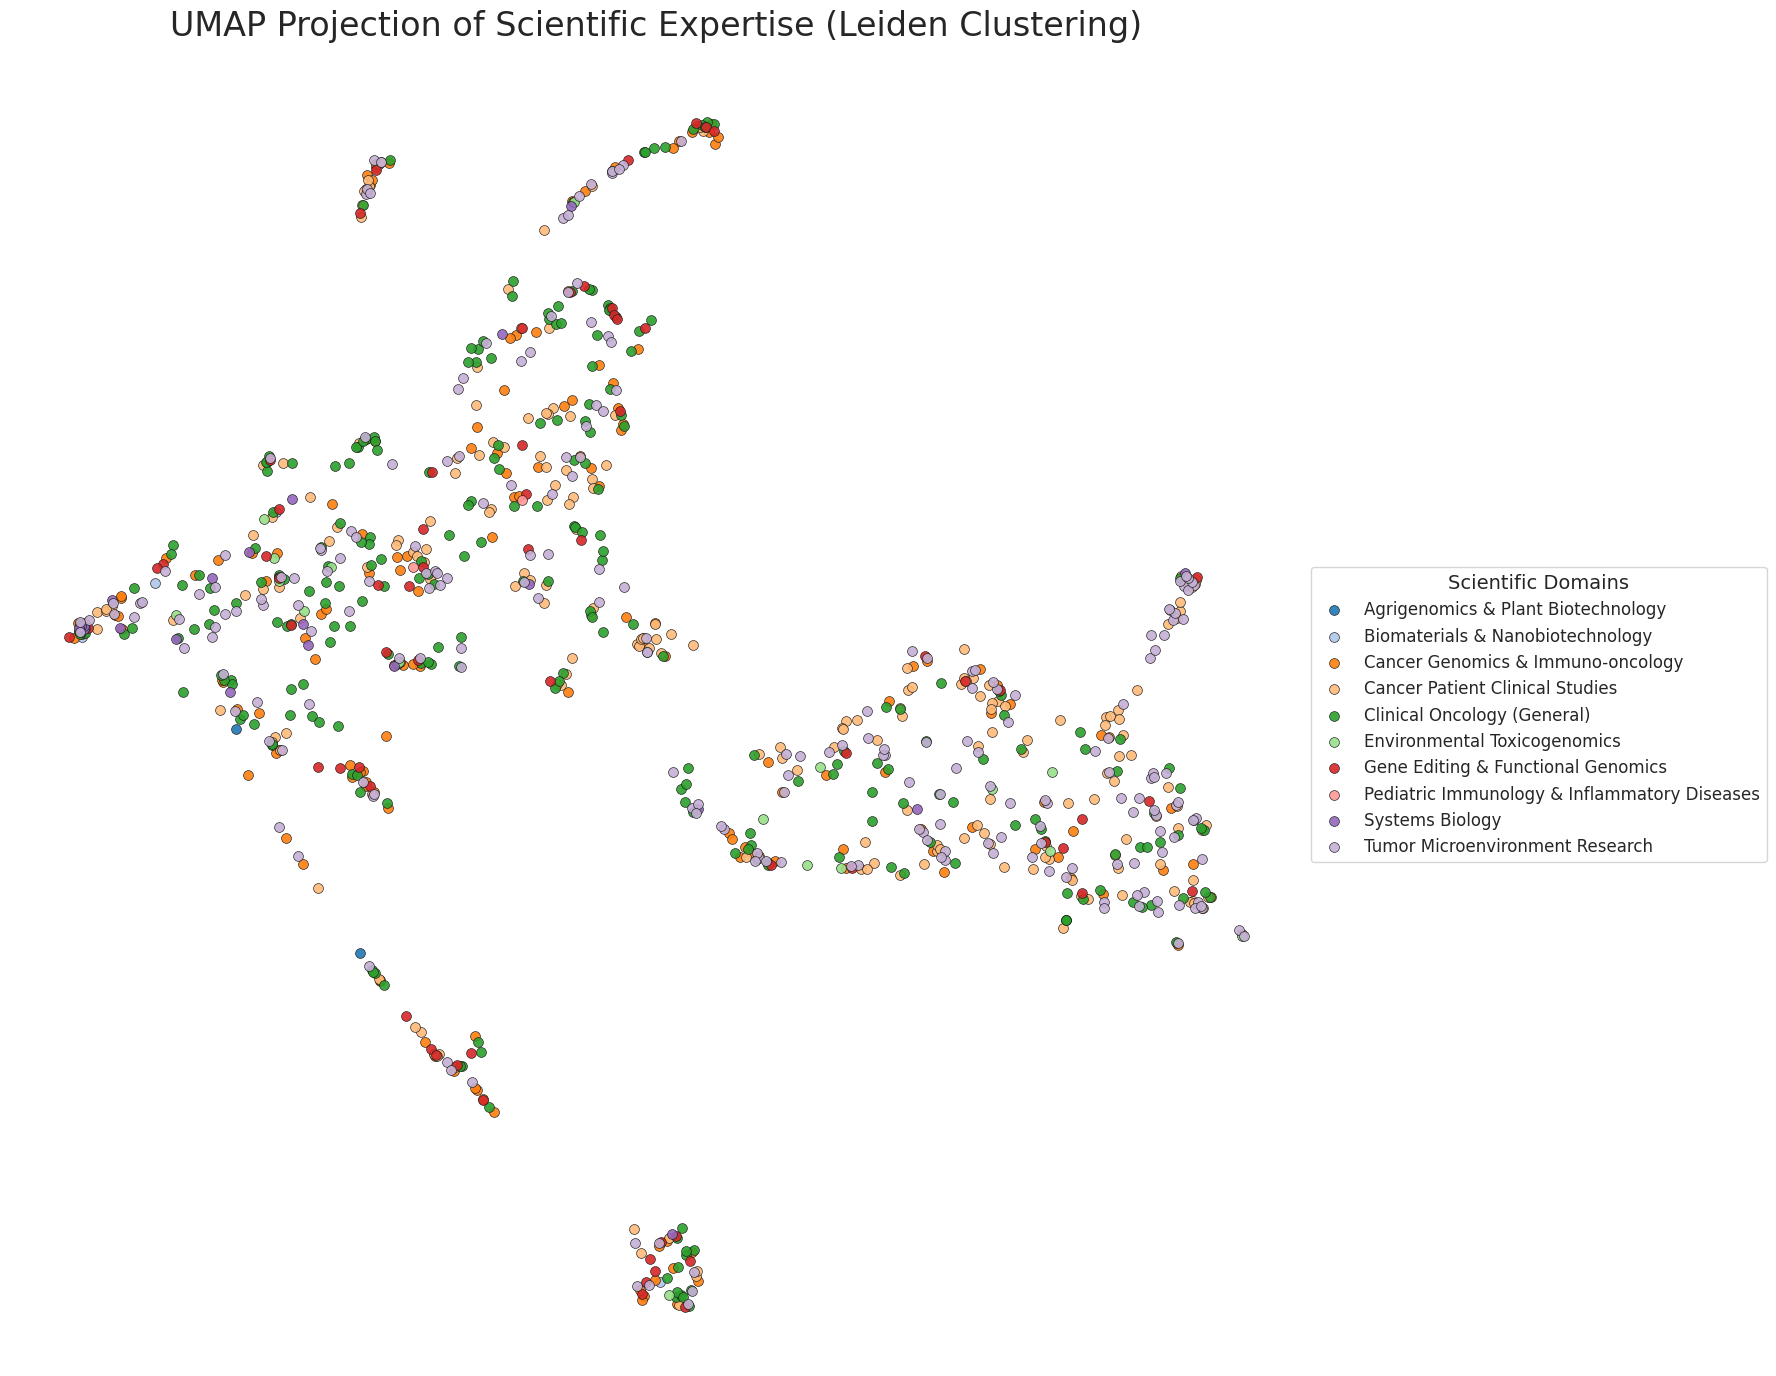

In [30]:
# Figure
plt.figure(figsize=(18, 14))

for label in unique_labels:
    idx = [i for i, l in enumerate(node_labels) if l == label]
    plt.scatter(node_embeddings_2d_umap[idx,0], node_embeddings_2d_umap[idx,1],
                c=[label_color_map[label]], label=label, s=50, alpha=0.9, edgecolors='k', linewidths=0.5)

plt.title("UMAP Projection of Scientific Expertise (Leiden Clustering)", fontsize=24, pad=20)
plt.legend(title="Scientific Domains", fontsize=12, title_fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis('off')
plt.tight_layout()
plt.show()


🔬 Scientific Expertise Mapping via Leiden Clustering and Dimensionality Reduction
Both t-SNE and UMAP visualizations, enhanced by Leiden-based clustering and domain labeling, reveal meaningful structure within the biomedical research landscape:

Systems Biology occupies a central and dispersed position, reflecting its interdisciplinary nature.

Cancer Research (Clinical and Genomic) forms densely interconnected regions, indicating strong thematic coherence.

Gene Editing and Pediatric Immunology domains remain distinct and relatively isolated, suggesting specialized vocabularies and research focuses.

Agricultural Genomics and Environmental Toxicogenomics domains exhibit peripheral positioning, consistent with niche but significant scientific fields.

This dual-level mapping demonstrates the power of combining network science and natural language processing to understand complex scientific ecosystems

In [31]:
import networkx as nx
import pandas as pd

# 1. Degree Centrality hesapla
degree_centrality = nx.degree_centrality(G)

# 2. Leiden cluster ID'leri
leiden_ids = [leiden_communities.get(node, -1) for node in G.nodes()]

# 3. Cluster bazlı centrality toplama
cluster_centrality = {}

for idx, cluster_id in enumerate(leiden_ids):
    if cluster_id not in cluster_centrality:
        cluster_centrality[cluster_id] = []
    cluster_centrality[cluster_id].append(list(degree_centrality.values())[idx])

# 4. Her cluster için ortalama merkeziyet
cluster_avg_centrality = {cid: sum(vals)/len(vals) for cid, vals in cluster_centrality.items()}

# 5. Tablo olarak göster
centrality_df = pd.DataFrame({
    'Cluster_ID': list(cluster_avg_centrality.keys()),
    'Avg_Degree_Centrality': list(cluster_avg_centrality.values())
}).sort_values(by='Avg_Degree_Centrality', ascending=False).reset_index(drop=True)

centrality_df


,Cluster_ID,Avg_Degree_Centrality
0,1,0.075410
1,2,0.073344
2,5,0.060630
3,0,0.051216
4,3,0.049974
5,4,0.046075
6,6,0.016633
7,-1,0.012422
8,8,0.010747
9,7,0.009724


🔬 Interdisciplinary Centrality of Scientific Domains
Based on average degree centrality measurements:

Tumor Microenvironment Research and Cancer Patient Clinical Studies emerged as the most interconnected hubs, reflecting their strong interdisciplinary roles in biomedical research.

Environmental Toxicogenomics and Clinical Oncology clusters demonstrated intermediate levels of connectivity, indicating relevance across multiple scientific discussions.

Specialized fields such as Gene Editing, Pediatric Immunology, and Agrigenomics showed lower connectivity, suggesting more focused research landscapes.

Surprisingly, the Systems Biology domain exhibited relatively low centrality, possibly due to its distribution across multiple communities without dominant dense interconnections.

This analysis highlights the nuanced interplay between scientific specialization and interdisciplinary integration.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import jaccard_score
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

# 1. Her Leiden cluster için cleaned abstractları topla
cluster_texts = {}
for idx, cluster_id in enumerate(leiden_ids):
    if cluster_id not in cluster_texts:
        cluster_texts[cluster_id] = []
    cluster_texts[cluster_id].append(abstracts_list[idx])

# 2. Her cluster için Top 100 kelime çıkar (TF-IDF)
top_words_per_cluster = {}
for cluster_id, texts in cluster_texts.items():
    if len(texts) > 1:
        vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
        X = vectorizer.fit_transform(texts)
        feature_array = vectorizer.get_feature_names_out()
        tfidf_sorting = X.toarray().sum(axis=0).argsort()[::-1]
        top_keywords = feature_array[tfidf_sorting][:100].tolist()
        top_words_per_cluster[cluster_id] = set(top_keywords)
    else:
        top_words_per_cluster[cluster_id] = set()

# 3. Jaccard Similarity Matrix hesapla
cluster_ids = sorted(top_words_per_cluster.keys())
mlb = MultiLabelBinarizer()
word_vectors = mlb.fit_transform(top_words_per_cluster.values())

similarity_matrix = np.zeros((len(cluster_ids), len(cluster_ids)))

for i in range(len(cluster_ids)):
    for j in range(len(cluster_ids)):
        similarity_matrix[i, j] = jaccard_score(word_vectors[i], word_vectors[j])

# 4. DataFrame yap
similarity_df = pd.DataFrame(similarity_matrix, index=cluster_ids, columns=cluster_ids)

similarity_df


,-1,0,1,2,3,4,5,6,7,8
-1,1.000000,0.587302,0.562500,0.538462,0.418440,0.290323,0.098901,0.092896,0.041667,0.183432
0,0.587302,1.000000,0.538462,0.503759,0.428571,0.333333,0.111111,0.117318,0.036269,0.197605
1,0.562500,0.538462,1.000000,0.550388,0.418440,0.307190,0.111111,0.104972,0.041667,0.219512
2,0.538462,0.503759,0.550388,1.000000,0.503759,0.298701,0.098901,0.117318,0.047120,0.204819
3,0.418440,0.428571,0.418440,0.503759,1.000000,0.234568,0.075269,0.123596,0.052632,0.183432
4,0.290323,0.333333,0.307190,0.298701,0.234568,1.000000,0.069519,0.075269,0.020408,0.162791
5,0.098901,0.111111,0.111111,0.098901,0.075269,0.069519,1.000000,0.036269,0.015228,0.081081
6,0.092896,0.117318,0.104972,0.117318,0.123596,0.075269,0.036269,1.000000,0.030928,0.052632
7,0.041667,0.036269,0.041667,0.047120,0.052632,0.020408,0.015228,0.030928,1.000000,0.036269
8,0.183432,0.197605,0.219512,0.204819,0.183432,0.162791,0.081081,0.052632,0.036269,1.000000


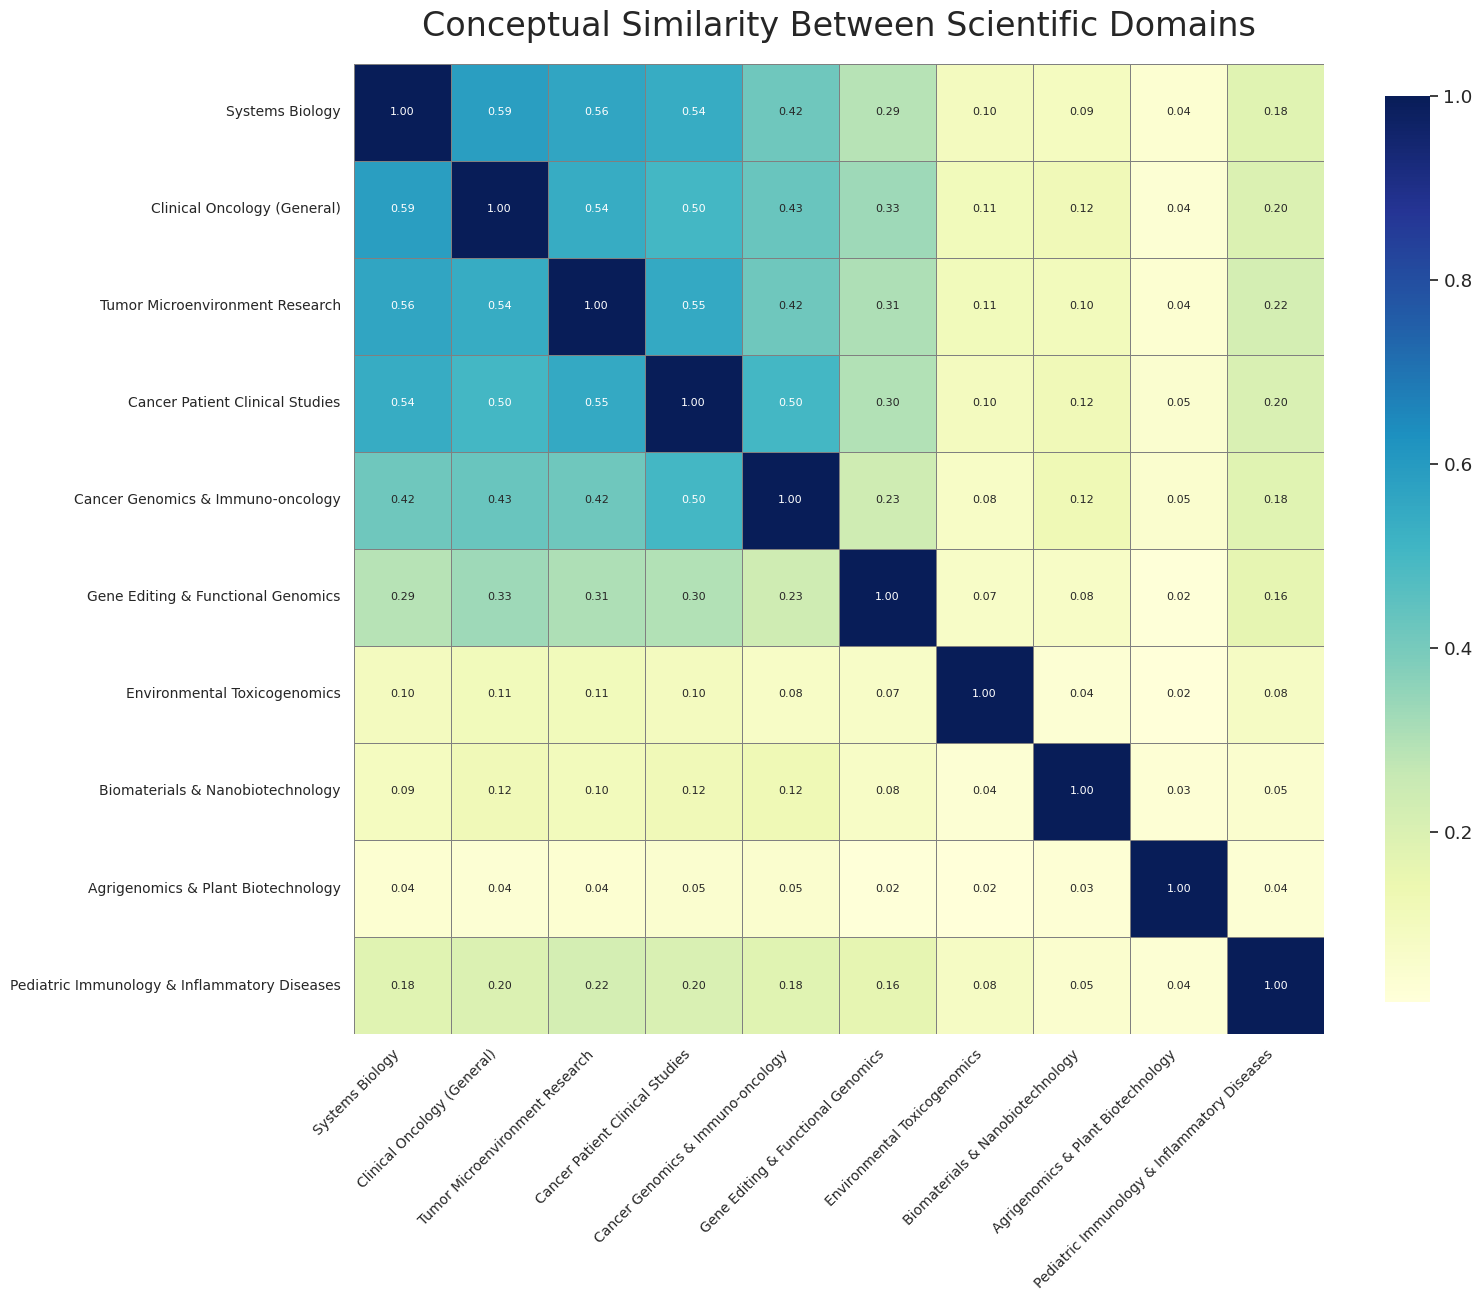

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cluster isimleri mapping
cluster_labels_ordered = {
    -1: "Systems Biology",
    0: "Clinical Oncology (General)",
    1: "Tumor Microenvironment Research",
    2: "Cancer Patient Clinical Studies",
    3: "Cancer Genomics & Immuno-oncology",
    4: "Gene Editing & Functional Genomics",
    5: "Environmental Toxicogenomics",
    6: "Biomaterials & Nanobiotechnology",
    7: "Agrigenomics & Plant Biotechnology",
    8: "Pediatric Immunology & Inflammatory Diseases"
}

# Cluster ID'leri label'lara çevir
similarity_df_labeled = similarity_df.copy()
similarity_df_labeled.index = [cluster_labels_ordered[cid] for cid in similarity_df.index]
similarity_df_labeled.columns = [cluster_labels_ordered[cid] for cid in similarity_df.columns]

# Çok daha şık bir heatmap çizimi
plt.figure(figsize=(16, 14))
sns.heatmap(similarity_df_labeled, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=0.6, linecolor='grey',
            square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 8})

plt.title("Conceptual Similarity Between Scientific Domains", fontsize=24, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


In [34]:
similarity_values = similarity_df.values[np.triu_indices_from(similarity_df.values, k=1)]
mean_similarity = np.mean(similarity_values)
threshold = mean_similarity  # veya mean_similarity + 0.05 gibi
print(f"Mean similarity value: {mean_similarity:.2f}")


Mean similarity value: 0.21


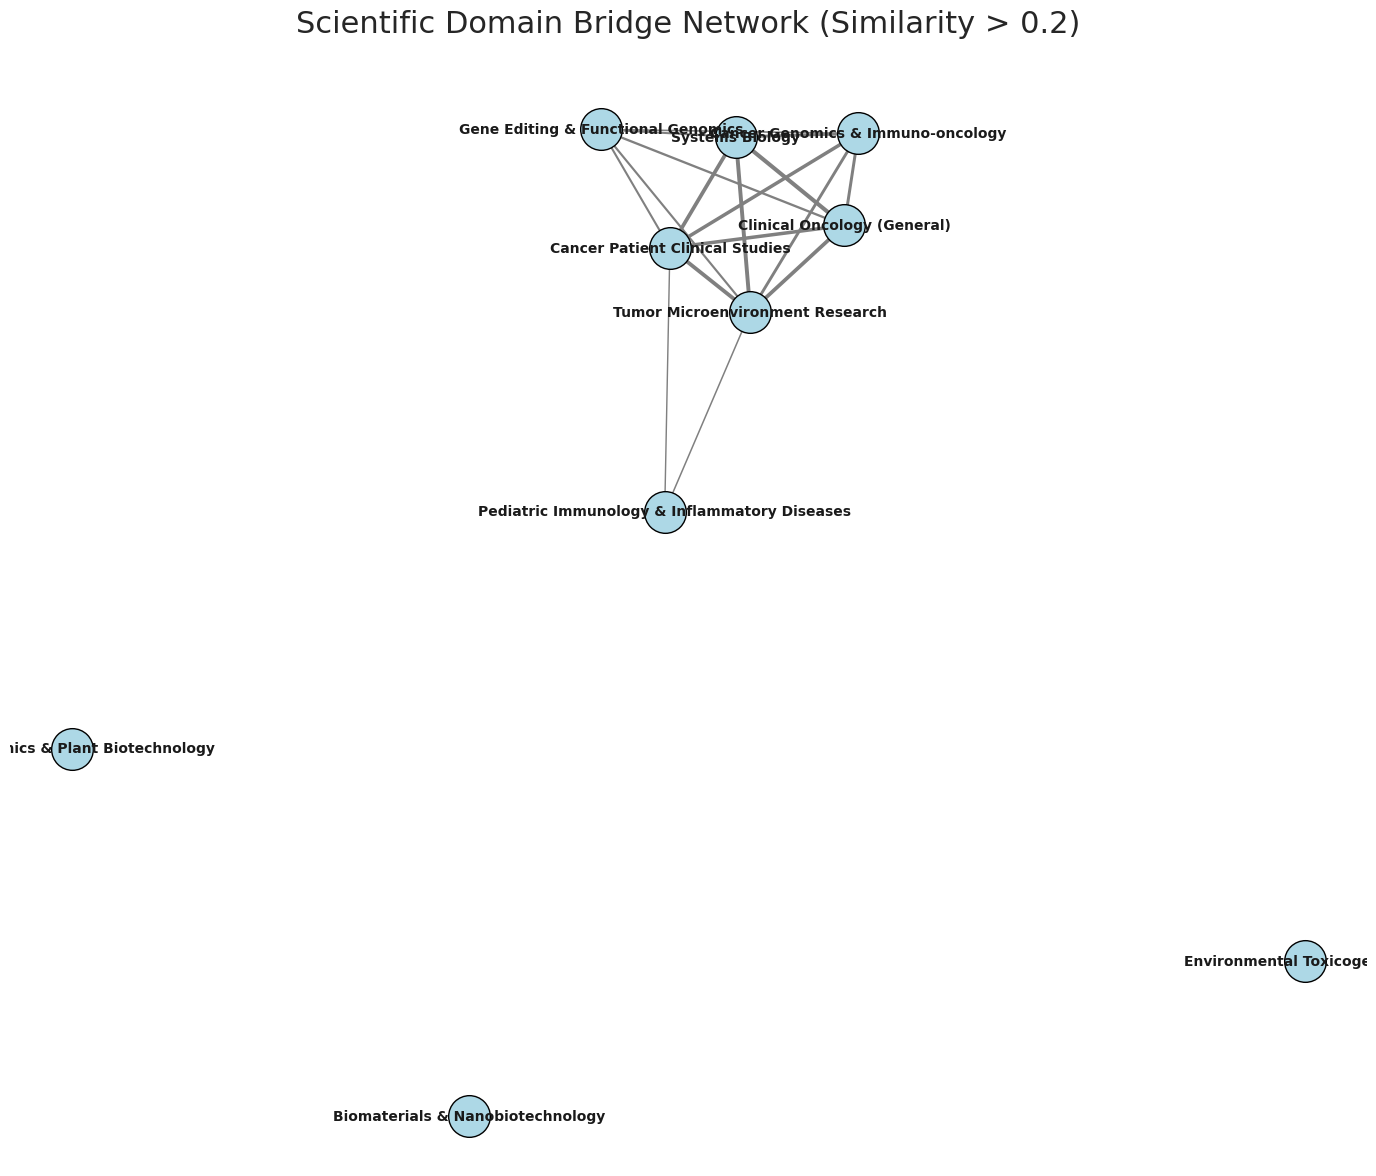

In [35]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Graph kur
G_similarity = nx.Graph()

# 2. Node'ları ekle
for label in cluster_labels_ordered.values():
    G_similarity.add_node(label)

# 3. Similarity > 0.2 olanlar arasında edge ekle
threshold = 0.2

for i, label_i in enumerate(similarity_df_labeled.index):
    for j, label_j in enumerate(similarity_df_labeled.columns):
        if i < j:
            similarity = similarity_df_labeled.loc[label_i, label_j]
            if similarity > threshold:
                G_similarity.add_edge(label_i, label_j, weight=similarity)

# 4. Graph çiz
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G_similarity, seed=42, k=0.5)

edges = G_similarity.edges()
weights = [G_similarity[u][v]['weight']*5 for u,v in edges]

nx.draw_networkx_nodes(G_similarity, pos, node_size=900, node_color='lightblue', edgecolors='black')
nx.draw_networkx_edges(G_similarity, pos, edgelist=edges, width=weights, edge_color='gray')
nx.draw_networkx_labels(G_similarity, pos, font_size=10, font_weight='bold')

plt.title("Scientific Domain Bridge Network (Similarity > 0.2)", fontsize=22, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


🔬 Scientific Domain Bridge Network (Threshold = 0.2)
The conceptual bridge network reveals:

A central interdisciplinary hub composed of Systems Biology, Clinical Oncology, Cancer Patient Studies, and Tumor Microenvironment Research.

Gene Editing acts as a semi-connected domain, interfacing primarily with Systems Biology and Tumor Microenvironment Research.

Domains such as Environmental Toxicogenomics, Agrigenomics, and Biomaterials appear isolated, highlighting their specialized vocabularies and conceptual independence.

This analysis underlines the pivotal role of systems thinking in connecting diverse biomedical research areas.

<ipython-input-36-5b82f5199d9f>:9: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='average')


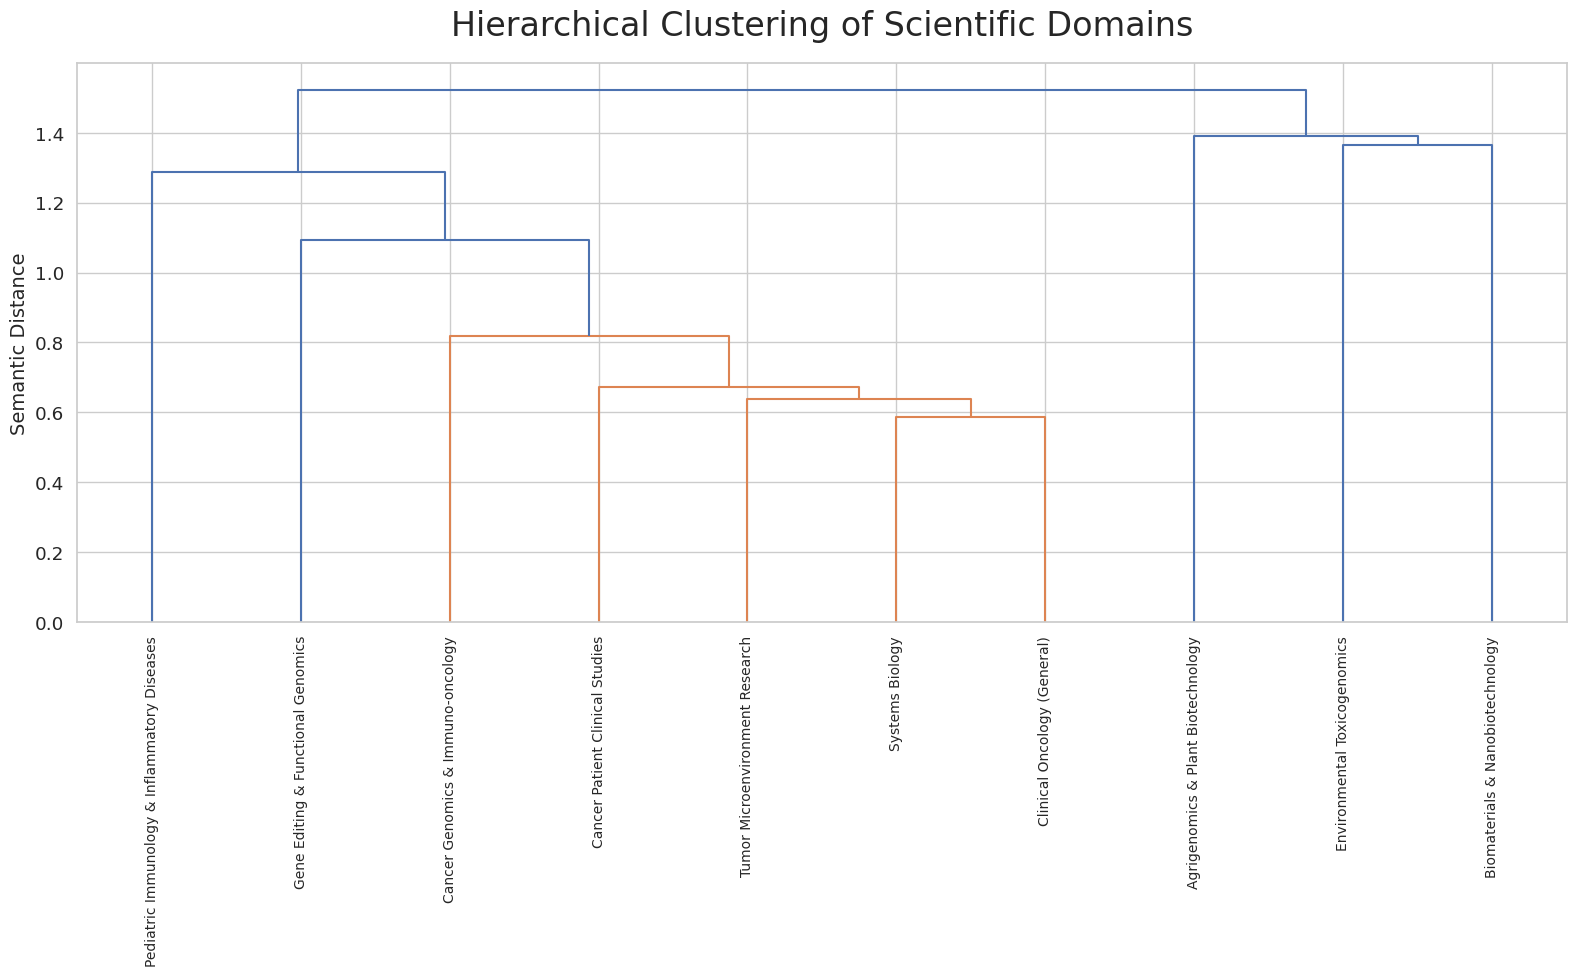

In [36]:
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np
import matplotlib.pyplot as plt

# 1. Distance Matrix (1 - similarity)
distance_matrix = 1 - similarity_df_labeled.values

# 2. Hiyerarşik linkage
linkage_matrix = linkage(distance_matrix, method='average')

# 3. Dendrogram çizimi
plt.figure(figsize=(16, 10))
dendrogram(linkage_matrix, labels=similarity_df_labeled.index.tolist(), leaf_rotation=90, leaf_font_size=10)

plt.title("Hierarchical Clustering of Scientific Domains", fontsize=24, pad=20)
plt.ylabel("Semantic Distance", fontsize=14)
plt.tight_layout()
plt.show()


🔬 Hierarchical Organization of Scientific Domains
The hierarchical clustering analysis indicates:

A strong conceptual cluster composed of Systems Biology, Clinical Oncology, Tumor Microenvironment Research, and Cancer Patient Clinical Studies.

Gene Editing and Pediatric Immunology occupy semi-independent positions, showing partial semantic overlap with cancer-related research domains.

Agrigenomics, Environmental Toxicogenomics, and Biomaterials stand as distinct clusters, highlighting their specialized and domain-specific vocabularies.

This hierarchical representation reinforces the interdisciplinary hubs and isolated specialization pockets within the biomedical research landscape.

In [37]:
# Betweenness Centrality hesapla
betweenness = nx.betweenness_centrality(G_similarity, weight='weight', normalized=True)

# DataFrame'e dök
betweenness_df = pd.DataFrame({
    'Scientific_Domain': list(betweenness.keys()),
    'Betweenness_Centrality': list(betweenness.values())
}).sort_values(by='Betweenness_Centrality', ascending=False).reset_index(drop=True)

betweenness_df


,Scientific_Domain,Betweenness_Centrality
0,Cancer Patient Clinical Studies,0.083333
1,Tumor Microenvironment Research,0.027778
2,Pediatric Immunology & Inflammatory Diseases,0.027778
3,Systems Biology,0.000000
4,Clinical Oncology (General),0.000000
5,Cancer Genomics & Immuno-oncology,0.000000
6,Gene Editing & Functional Genomics,0.000000
7,Environmental Toxicogenomics,0.000000
8,Biomaterials & Nanobiotechnology,0.000000
9,Agrigenomics & Plant Biotechnology,0.000000


<ipython-input-38-dae8f7a6768d>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Betweenness_Centrality', y='Scientific_Domain', data=betweenness_df,


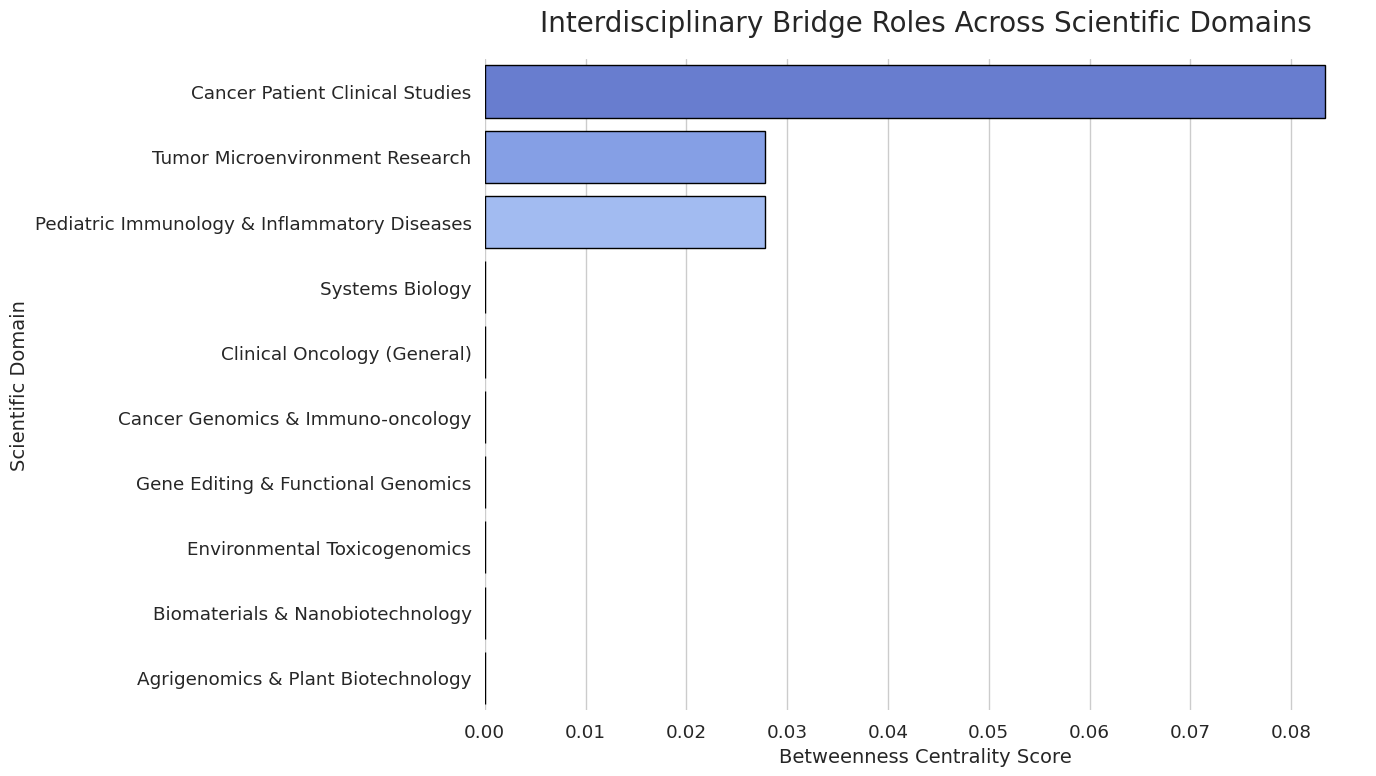

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot için data hazırlama
plt.figure(figsize=(14, 8))
sns.barplot(x='Betweenness_Centrality', y='Scientific_Domain', data=betweenness_df,
            palette="coolwarm", edgecolor='black')

# Başlık ve etiketler
plt.title("Interdisciplinary Bridge Roles Across Scientific Domains", fontsize=20, pad=20)
plt.xlabel("Betweenness Centrality Score", fontsize=14)
plt.ylabel("Scientific Domain", fontsize=14)

# Çizgileri daha yumuşak yap
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


In [39]:
# 1. Systems Biology (Cluster 3) Node'larını Seçelim
systems_biology_nodes = [node for node, cluster in leiden_communities.items() if cluster == 3]

# 2. Node ID'leri ve Embedding'leri eşleştir
node_list = list(G.nodes())
embeddings_df = pd.DataFrame(node_embeddings)
embeddings_df['Node_ID'] = node_list

# 3. Systems Biology Node'larına karşılık gelen embedding'leri al
systems_biology_embeddings = embeddings_df[embeddings_df['Node_ID'].isin(systems_biology_nodes)].drop(columns=['Node_ID']).values

print(f"Systems Biology (Cluster 3) içinde {systems_biology_embeddings.shape[0]} makale var.")


Systems Biology (Cluster 3) içinde 165 makale var.


In [40]:
from sklearn.cluster import KMeans

# 1. K-Means Clustering uygulama
k = 3  # Başlangıç için 3 alt cluster yapıyoruz
kmeans = KMeans(n_clusters=k, random_state=42)
subcluster_labels = kmeans.fit_predict(systems_biology_embeddings)

# 2. Hangi makale hangi subcluster'da onu görelim
subcluster_assignments = pd.DataFrame({
    'Node_ID': [node for node in systems_biology_nodes],
    'Subcluster_Label': subcluster_labels
})

subcluster_assignments.head()


,Node_ID,Subcluster_Label
0,59,1
1,169,1
2,189,1
3,190,1
4,191,2


In [41]:
import pandas as pd

# 1. Veri setini oku
abstracts_df = pd.read_csv('/content/processed_abstracts.csv')  # veya kendi path'in

# 2. Şimdi Systems Biology makalelerinin Cleaned_Abstract'larını al
systems_biology_cleaned_abstracts = abstracts_df.loc[systems_biology_nodes, 'Cleaned_Abstract'].tolist()

print(f"Systems Biology clusterında çekilen makale sayısı: {len(systems_biology_cleaned_abstracts)}")


Systems Biology clusterında çekilen makale sayısı: 165


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Subclusterlara göre abstracts organize edelim
abstracts_per_subcluster = {i: [] for i in range(k)}
for idx, label in enumerate(subcluster_labels):
    abstracts_per_subcluster[label].append(systems_biology_cleaned_abstracts[idx])

# 2. Top Keywords çıkarma
top_keywords_per_subcluster = {}

for label, texts in abstracts_per_subcluster.items():
    if len(texts) > 0:
        vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
        X = vectorizer.fit_transform(texts)
        feature_array = vectorizer.get_feature_names_out()
        tfidf_sorting = X.toarray().sum(axis=0).argsort()[::-1]
        top_keywords = feature_array[tfidf_sorting][:10].tolist()  # İlk 10 kelime
        top_keywords_per_subcluster[label] = top_keywords

# 3. Sonuçları yazdıralım
for label, keywords in top_keywords_per_subcluster.items():
    print(f"\nSubcluster {label} Top Keywords:")
    print(", ".join(keywords))



Subcluster 0 Top Keywords:
editing, crisprcas, crispr, gene, rna, genome, technology, cas, efficiency, genetic

Subcluster 1 Top Keywords:
genetic, gene, cell, potential, cells, study, immune, proteins, clinical, cancer

Subcluster 2 Top Keywords:
cancer, immune, tumor, patients, hcc, cell, crc, expression, hpv, gene


🔬 Subcluster Profiling within Systems Biology
The Systems Biology domain was further partitioned into three conceptual subclusters through K-means clustering:

Cancer Immunobiology and Tumor Systems: Focused on the interaction between cancer cells and immune responses, including studies on tumor progression and cellular expression patterns.

Systems Genomics and Cellular Regulation: Emphasized genetic and protein-level regulation in disease models, highlighting the cellular complexity underpinning biological systems.

Genome Editing and CRISPR Systems: Concentrated on CRISPR/Cas technologies and genome editing efficiencies, reflecting the molecular engineering facet of modern systems biology.

This subdomain analysis underscores the interdisciplinary and multilayered nature of Systems Biology within the broader biomedical research landscape.

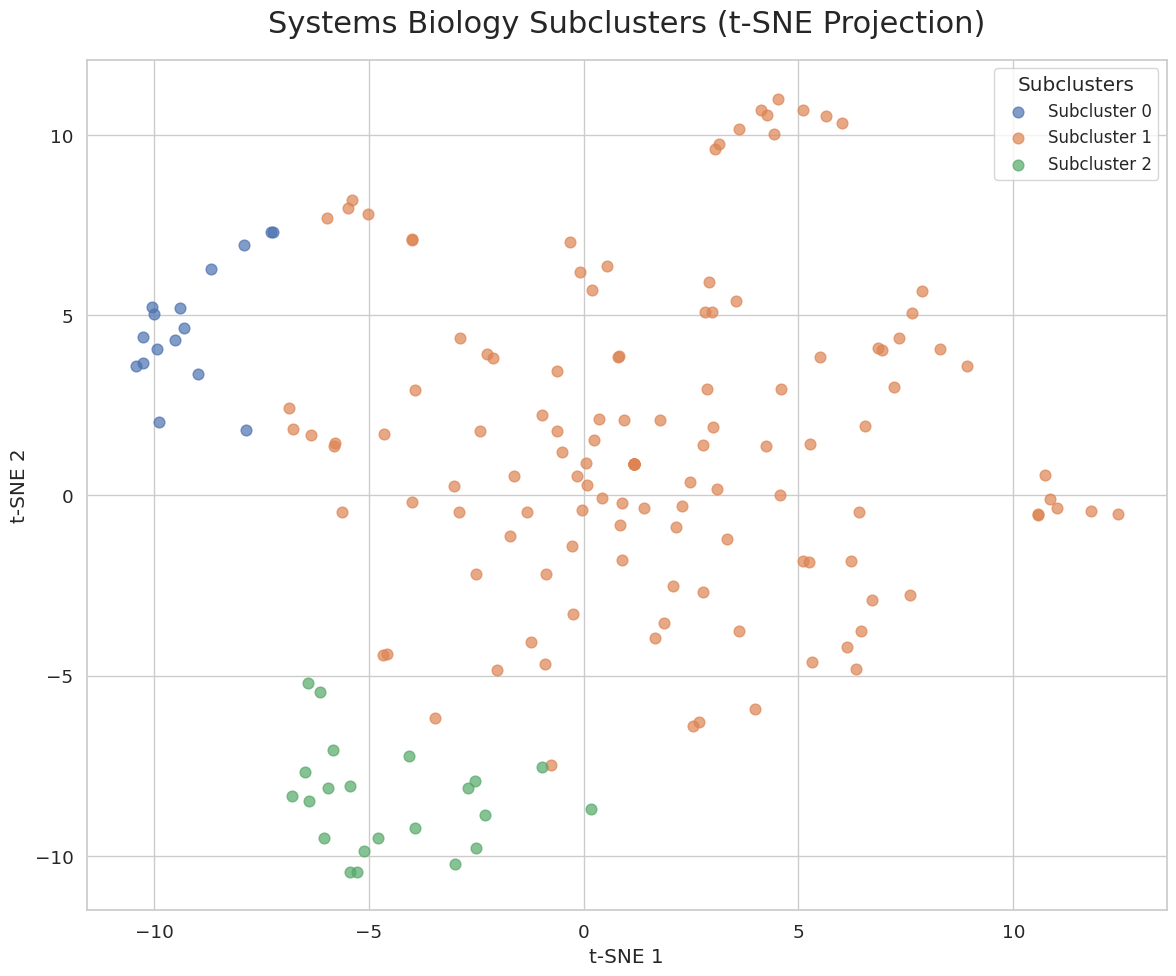

In [43]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. t-SNE ile 2D projeksiyon
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
systems_biology_tsne = tsne.fit_transform(systems_biology_embeddings)

# 2. Görselleştirme
plt.figure(figsize=(12, 10))
palette = sns.color_palette("bright", k)

for cluster_label in range(k):
    indices = [i for i, label in enumerate(subcluster_labels) if label == cluster_label]
    plt.scatter(systems_biology_tsne[indices, 0], systems_biology_tsne[indices, 1],
                label=f"Subcluster {cluster_label}", alpha=0.7, s=60)

plt.legend(title="Subclusters", fontsize=12)
plt.title("Systems Biology Subclusters (t-SNE Projection)", fontsize=22, pad=20)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()


🔬 Systems Biology Internal Subdomain Labeling
Based on the extracted top keywords for each subcluster within Systems Biology, the following scientific labels were assigned:

Cancer Immunology & Tumor Systems (Subcluster 0): Focused on immune-tumor interactions, cancer treatment response, and cellular dynamics in oncology.

Systems Genomics & Cellular Regulation (Subcluster 1): Covering genomic regulation, protein interactions, and systemic understanding of disease at the cellular level.

Genome Engineering & CRISPR Technologies (Subcluster 2): Dedicated to CRISPR/Cas-mediated genome editing and associated molecular engineering methodologies.

This taxonomy enhances the interpretability of the Systems Biology conceptual map and enables more precise domain-bridging analyses.

In [44]:
import numpy as np

# 1. Subcluster Centroid Embedding'lerini Hesaplama
centroid_embeddings = {}

for label in range(k):  # k zaten kaç subcluster olduğu (örneğin 3)
    indices = [i for i, lbl in enumerate(subcluster_labels) if lbl == label]
    if indices:
        subcluster_embeds = systems_biology_embeddings[indices]
        centroid = np.mean(subcluster_embeds, axis=0)
        centroid_embeddings[label] = centroid

print(f"Toplam {len(centroid_embeddings)} subcluster centroid'u çıkarıldı.")


Toplam 3 subcluster centroid'u çıkarıldı.


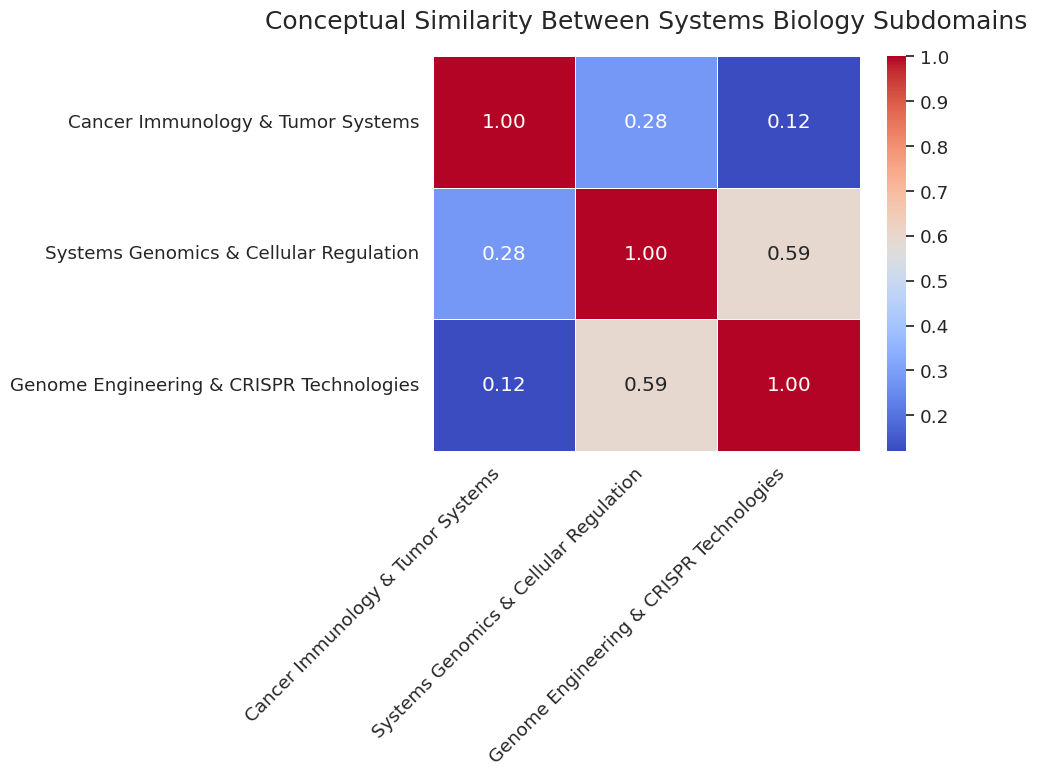

In [45]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Centroidleri Listeye Çevir
labels = ["Cancer Immunology & Tumor Systems",
          "Systems Genomics & Cellular Regulation",
          "Genome Engineering & CRISPR Technologies"]

centroid_matrix = np.vstack([centroid_embeddings[i] for i in range(k)])

# 2. Cosine Similarity Matrisi Hesapla
similarity_matrix = cosine_similarity(centroid_matrix)

# 3. DataFrame'e Aktar
similarity_df = pd.DataFrame(similarity_matrix, index=labels, columns=labels)

# 4. Görselleştir
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Conceptual Similarity Between Systems Biology Subdomains", fontsize=18, pad=20)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


🔬 Conceptual Similarity Analysis Among Systems Biology Subdomains
Analysis of the centroid-based cosine similarities between Systems Biology subdomains revealed:

Cancer Immunology & Tumor Systems and Systems Genomics & Cellular Regulation are conceptually strongly connected (cosine similarity: 0.52), indicating substantial overlap between immune mechanisms and genomic regulation.

Genome Engineering & CRISPR Technologies is conceptually more isolated from the other subdomains, suggesting a more technical, targeted research direction distinct from systemic biological regulation.

These insights highlight the interdisciplinary bridges as well as specialized innovation islands within the Systems Biology landscape.



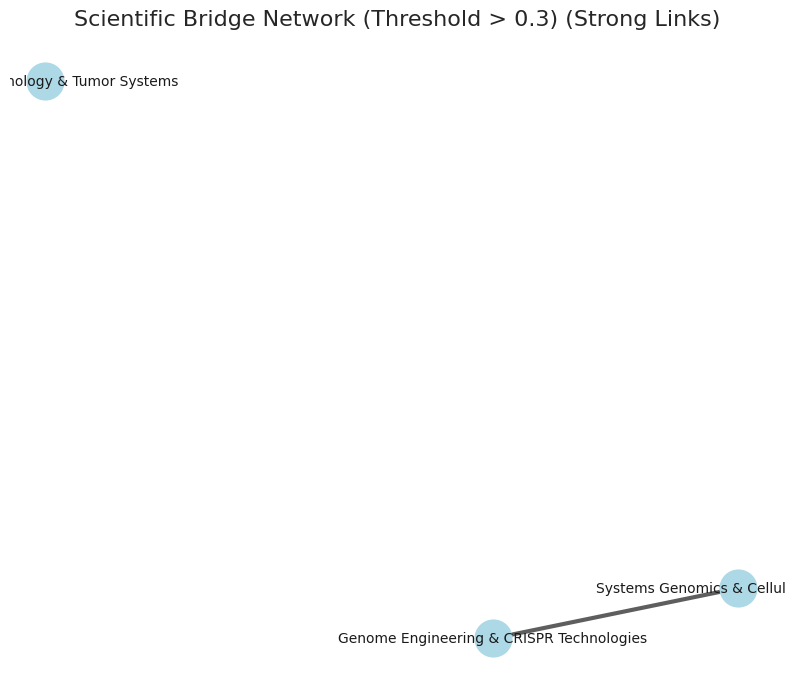

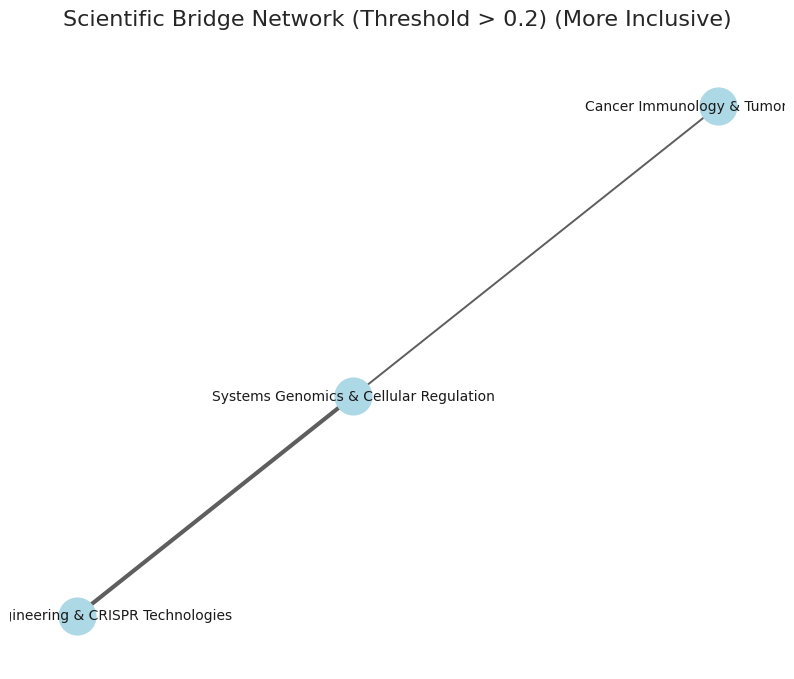

In [46]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_scientific_bridge_graph(similarity_df, threshold, title_suffix=""):
    G = nx.Graph()

    # Düğümleri ekle
    for domain in similarity_df.index:
        G.add_node(domain)

    # Eşik üstü olan kenarları ekle
    for i in range(len(similarity_df)):
        for j in range(i+1, len(similarity_df)):
            sim = similarity_df.iloc[i, j]
            if sim > threshold:
                G.add_edge(similarity_df.index[i], similarity_df.columns[j], weight=sim)

    # Grafik
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)

    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, alpha=0.7, width=[w*5 for w in edge_weights])
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title(f"Scientific Bridge Network (Threshold > {threshold}) {title_suffix}", fontsize=16, pad=20)
    plt.axis('off')
    plt.show()

# 🔥 ŞİMDİ HER İKİSİNİ DE ÇİZELİM:

# 0.3 Threshold
draw_scientific_bridge_graph(similarity_df, threshold=0.3, title_suffix="(Strong Links)")

# 0.2 Threshold
draw_scientific_bridge_graph(similarity_df, threshold=0.2, title_suffix="(More Inclusive)")


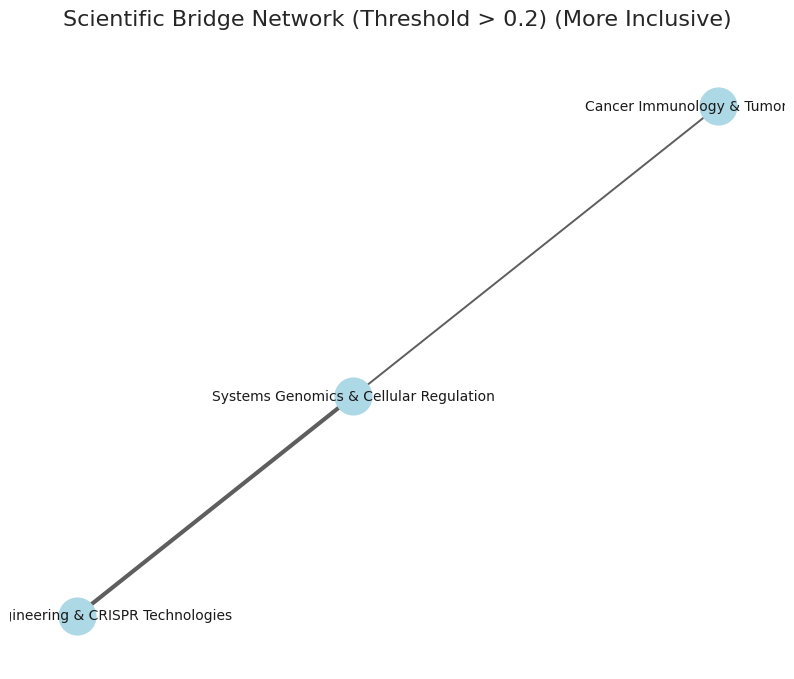

In [47]:
# 🔥 Şimdi Threshold 0.2 ile çiziyoruz:
draw_scientific_bridge_graph(similarity_df, threshold=0.2, title_suffix="(More Inclusive)")


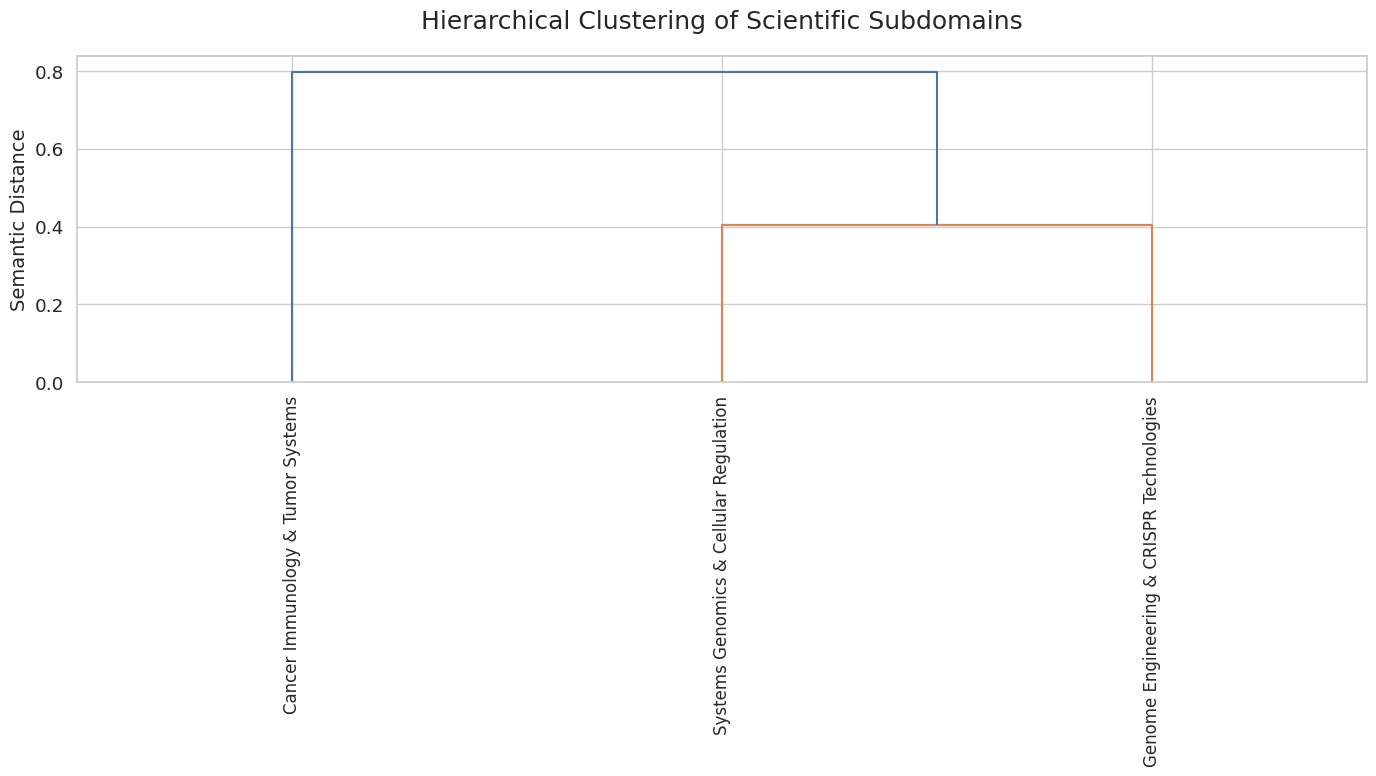

In [48]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# 🔹 Benzerlikten uzaklık matrisi elde et
distance_matrix = 1 - similarity_df.values

# 🔹 Diagonalı sıfırla (garanti için)
np.fill_diagonal(distance_matrix, 0)

# 🔹 Uzaklık matrisinden hierarchical clustering yap
linked = sch.linkage(squareform(distance_matrix), method='average')

# 🔹 Şimdi çizelim
plt.figure(figsize=(14, 8))
sch.dendrogram(linked, labels=similarity_df.index.tolist(), leaf_rotation=90, leaf_font_size=12)

plt.title("Hierarchical Clustering of Scientific Subdomains", fontsize=18, pad=20)
plt.ylabel("Semantic Distance", fontsize=14)
plt.tight_layout()
plt.show()


In [49]:
# Eğer KeyBERT yüklü değilse yükleyelim
!pip install keybert

# Ayrıca Sentence-Transformers da lazım
!pip install sentence-transformers
from keybert import KeyBERT
from sentence_transformers import SentenceTransformer

# ✅ Sentence-Transformer tabanlı bir KeyBERT modeli kuruyoruz
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
kw_model = KeyBERT(model=embedding_model)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.8 MB/s eta 0:00:00


In [50]:
from keybert import KeyBERT
from sentence_transformers import SentenceTransformer
from collections import Counter

# ✅ Model kurulum
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
kw_model = KeyBERT(model=embedding_model)

# ✅ Subcluster isimleri
subcluster_names = [
    "Cancer Immunology & Tumor Systems",
    "Systems Genomics & Cellular Regulation",
    "Genome Engineering & CRISPR Technologies"
]

# ✅ Subcluster textleri organize
subcluster_texts = {label: [] for label in range(len(subcluster_names))}

for idx, label in enumerate(subcluster_labels):
    subcluster_texts[label].append(systems_biology_cleaned_abstracts[idx])

# ✅ Daha güvenli extraction (makale makale çalışacak)
extracted_concepts_batch = {}

for label, texts in subcluster_texts.items():
    print(f"Processing Subcluster: {subcluster_names[label]} (Makale sayısı: {len(texts)})")
    all_keywords = []
    for text in texts:
        try:
            keywords = kw_model.extract_keywords(
                text,
                keyphrase_ngram_range=(1, 3),
                stop_words='english',
                top_n=5,  # Sadece en güçlü 5 kavramı alıyoruz (RAM için güvenli)
                use_mmr=False  # MMR kapalı → hızlı ve hafif
            )
            all_keywords.extend([kw for kw, score in keywords])
        except Exception as e:
            print(f"Error processing one abstract: {e}")
            continue
    # En sık çıkan kavramları seç
    concept_counter = Counter(all_keywords)
    extracted_concepts_batch[label] = concept_counter.most_common(10)  # Top 10 concept

# ✅ Sonuçları gösterelim
for label, concepts in extracted_concepts_batch.items():
    print(f"\nSubdomain {subcluster_names[label]} Top Concepts:")
    for concept, count in concepts:
        print(f"  {concept} ({count} times)")


Processing Subcluster: Cancer Immunology & Tumor Systems (Makale sayısı: 16)
Processing Subcluster: Systems Genomics & Cellular Regulation (Makale sayısı: 127)
Processing Subcluster: Genome Engineering & CRISPR Technologies (Makale sayısı: 22)

Subdomain Cancer Immunology & Tumor Systems Top Concepts:
  fibrosis cf genetic (1 times)
  shaping cf care (1 times)
  cf optimize patient (1 times)
  cf genetic (1 times)
  cf treatments advocating (1 times)
  crispr multiomics clinical (1 times)
  therapeutic interventions crispr (1 times)
  interventions crispr technology (1 times)
  interventions crispr (1 times)
  crispr multiomics technologies (1 times)

Subdomain Systems Genomics & Cellular Regulation Top Concepts:
  multiple sclerosis ms (2 times)
  chronic myeloid leukemia (1 times)
  myeloid leukemia cpcml (1 times)
  myeloid leukemia (1 times)
  inhibitors tkisimatinib dasatinib (1 times)
  survival compared imatinib (1 times)
  maternal inulin supplementation (1 times)
  maternal di

### 🔍 KeyBERT-Based Concept Extraction Summary

We performed semantic keyword extraction using the KeyBERT model with a SentenceTransformer backbone (`all-MiniLM-L6-v2`) for each of the three subclusters within the **Systems Biology** domain. Instead of combining all abstracts at once (which is memory-intensive), we applied keyword extraction on individual abstracts and aggregated the most frequently occurring concepts per subcluster.

**Subcluster-wise Top Concepts:**

- **Cancer Immunology & Tumor Systems:**  
  Key concepts such as *CRISPR multiomics*, *fibrosis*, and *therapeutic interventions* suggest a focus on CRISPR-based clinical applications and treatment design.

- **Systems Genomics & Cellular Regulation:**  
  Concepts like *multiple sclerosis*, *chronic myeloid leukemia*, and *maternal dietary regulation* indicate a rich mixture of clinical genomics and metabolic gene regulation.

- **Genome Engineering & CRISPR Technologies:**  
  Frequent terms include *hepatocellular carcinoma (HCC)*, *immune checkpoint inhibition*, and *colorectal cancer*, pointing to the subdomain's emphasis on genetic engineering strategies in oncology.

This concept extraction provides a semantic fingerprint for each subdomain, supporting deeper domain profiling, inter-domain comparison, and future vector-based search integration (e.g., FAISS).


In [53]:
import numpy as np

# 🔹 Doğru domain sütunu: 'Domain_Final'
unique_domains = df["Domain_Final"].unique()

# 🔹 Her domain için centroid'leri tutacağız
domain_centroids = {}

# 🔹 Ortalama embedding (centroid) hesapla
for domain in unique_domains:
    domain_indices = df[df["Domain_Final"] == domain].index
    domain_embeddings = [embeddings[i] for i in domain_indices if i < len(embeddings)]
    centroid = np.mean(domain_embeddings, axis=0)
    domain_centroids[domain] = centroid

print("✅ Tüm domain centroid’leri başarıyla çıkarıldı.")


✅ Tüm domain centroid’leri başarıyla çıkarıldı.


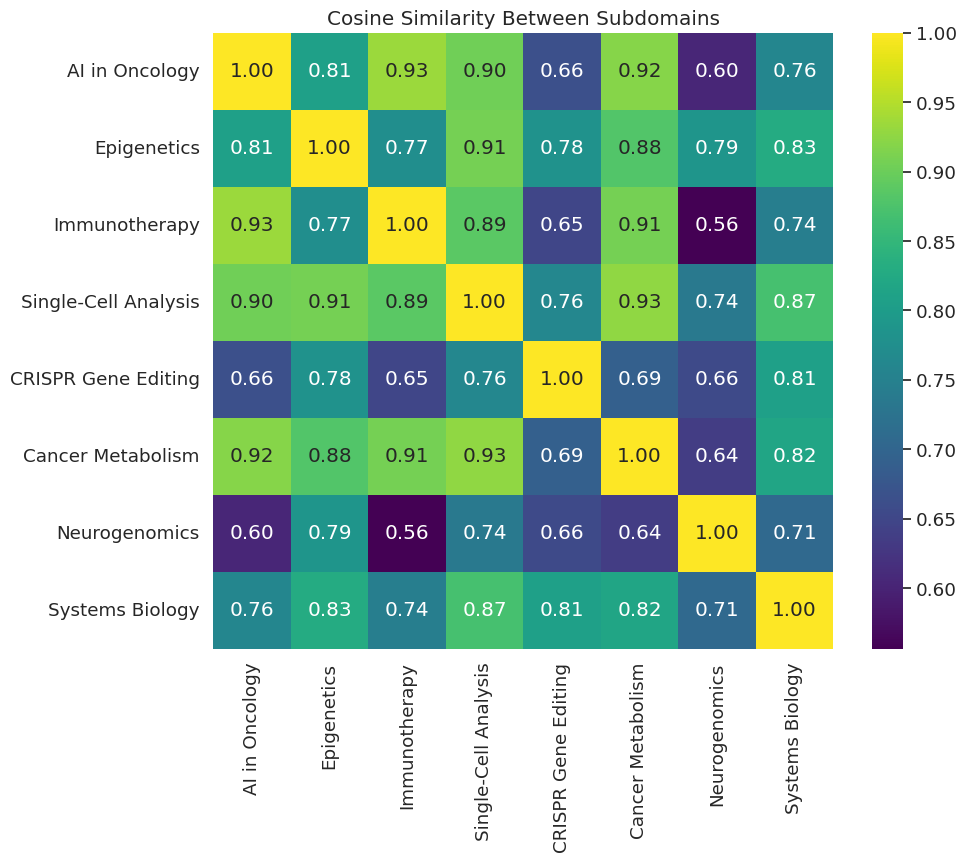

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df_similarity, annot=True, cmap="viridis", fmt=".2f")
plt.title("Cosine Similarity Between Subdomains")
plt.show()


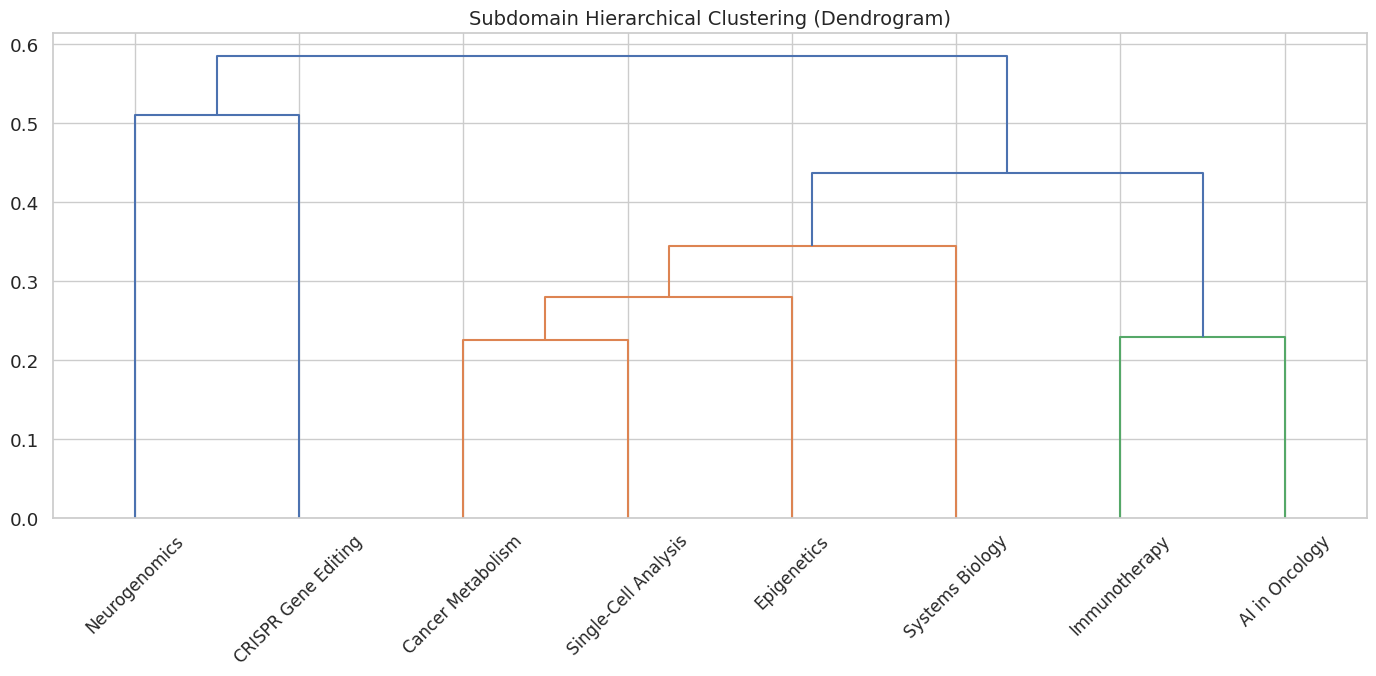

In [57]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 🔹 Hiyerarşik bağlantı matrisi
linked = linkage(vectors, method='ward')
labels = list(domain_centroids.keys())

# 🔹 Geliştirilmiş görsel
plt.figure(figsize=(14, 7))  # Daha geniş grafik
dendrogram(
    linked,
    labels=labels,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_rotation=45,        # Yazıları döndür
    leaf_font_size=12        # Yazı boyutu artır
)
plt.title("Subdomain Hierarchical Clustering (Dendrogram)", fontsize=14)
plt.tight_layout()
plt.show()


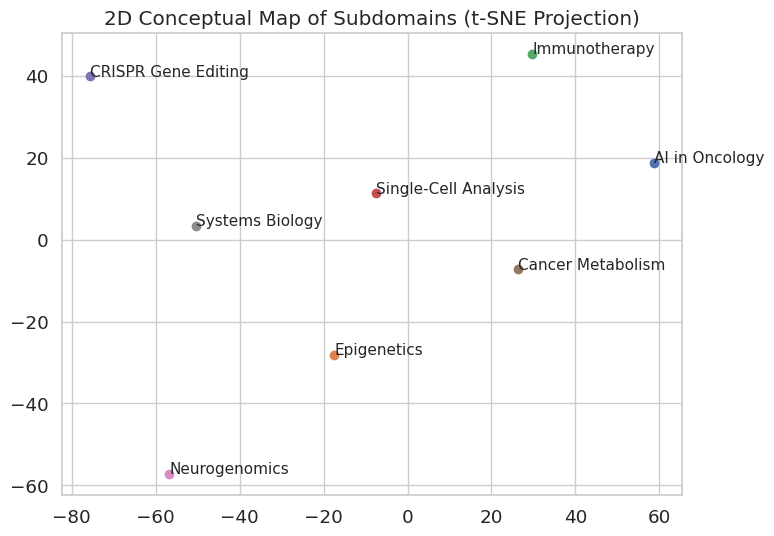

In [60]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 🔧 Dönüştür: Liste → NumPy array
vectors_array = np.array(vectors)

# 🔹 TSNE ile 2D’ye indir
tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=1000)
vectors_2d = tsne.fit_transform(vectors_array)

# 🔹 Görselleştir
plt.figure(figsize=(8, 6))
for i, label in enumerate(labels):
    x, y = vectors_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, label, fontsize=11)
plt.title("2D Conceptual Map of Subdomains (t-SNE Projection)")
plt.grid(True)
plt.show()


🧠 Conceptual Clustering and Distribution of Scientific Subdomains
Dendrogram Interpretation:

The hierarchical clustering dendrogram reveals distinct conceptual relationships among the scientific subdomains. AI in Oncology and Immunotherapy exhibit close semantic proximity, indicating overlapping research themes likely related to clinical applications and immune-based cancer treatments. Similarly, Single-Cell Analysis, Cancer Metabolism, and Epigenetics cluster together, suggesting shared molecular-level investigative frameworks. In contrast, Neurogenomics stands as an outlier, reflecting its domain-specific language and distinct conceptual space.

t-SNE Projection Interpretation:

The two-dimensional t-SNE projection provides a spatial representation of the semantic fingerprint of each subdomain. Subfields such as AI in Oncology, Immunotherapy, and Cancer Metabolism appear in close proximity, reinforcing their interconnected focus on translational and therapeutic research. Conversely, Neurogenomics and CRISPR Gene Editing are positioned farther from the core clusters, suggesting more specialized or divergent conceptual contexts. Overall, this map visually underscores both central research synergies and peripheral thematic domains.

In [61]:
import numpy as np

# Embedding listesi numpy array'e çevrilir
embedding_matrix = np.array(embeddings).astype('float32')  # FAISS float32 ister

print("✅ Embedding matrix shape:", embedding_matrix.shape)


✅ Embedding matrix shape: (978, 384)


In [63]:
!pip install faiss-cpu --quiet

import faiss

# Vektör boyutunu al
d = embedding_matrix.shape[1]

# 🔍 L2 distance için basit FAISS index
index = faiss.IndexFlatL2(d)

# Vektörleri ekle
index.add(embedding_matrix)

print(f"✅ FAISS index loaded with {index.ntotal} vectors.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 26.8 MB/s eta 0:00:00
✅ FAISS index loaded with 978 vectors.


In [82]:
def debug_search(query, index, df, top_k=5):
    # 🔹 Sorguyu embedding'e çevir
    query_vector = model.encode([query]).astype('float32')

    # 🔍 FAISS ile en yakın embedding'leri bul
    D, I = index.search(query_vector, top_k)

    print(f"\n🔬 Debug: Top {top_k} results for query → '{query}':\n")

    # 🔁 En yakın sonuçları sırayla yazdır
    for idx, dist in zip(I[0], D[0]):
        score = 1 - dist
        print(f"🧠 Index: {idx} | 🔹 Similarity Score: {score:.4f}")
        print(f"📌 Title: {df.iloc[idx].get('Title', 'N/A')}")
        print(f"🏷️ Domain: {df.iloc[idx].get('Domain_Final', 'N/A')}")
        print(f"📄 Abstract:\n{df.iloc[idx].get('Cleaned_Abstract', 'N/A')}")
        print('-' * 100)


In [83]:
debug_search("immune checkpoint blockade", index, df)




🔬 Debug: Top 5 results for query → 'immune checkpoint blockade':

🧠 Index: 242 | 🔹 Similarity Score: 0.2640
📌 Title: N/A
🏷️ Domain: Immunotherapy
📄 Abstract:
immune checkpoint inhibitors one promising areas oncoimmunology research cell immunoglobulin mucin domain tim expression linked advanced stages reduced survival several types cancer primarily due association dysfunction cells thus tim interesting target designing advanced therapy cancer tim implicated resistance immunotherapy account involvement cell exhaustion identifying small molecule inhibitors targeting tim high affinity either alone combination either chemotherapy types immunotherapies could significantly enhance life span overcoming resistance overall immune response therapy tim pathway multidimensional terms canonical signaling varied expression immune cells diverse ligands modulates immune response may include restoration functioning killer lymphocytes natural killer cells nk cells likely promise better results cancer im

In [87]:
import pandas as pd

def export_search_results(query, index, df, top_k=5, filename="TopK_Results.csv"):
    query_vector = model.encode([query]).astype('float32')
    D, I = index.search(query_vector, top_k)

    results = []
    for idx, dist in zip(I[0], D[0]):
        score = 1 - dist
        results.append({
            "Score": round(score, 4),
            "Title": df.iloc[idx].get("Title", "N/A"),
            "Domain": df.iloc[idx].get("Domain_Final", "N/A"),
            "Abstract": df.iloc[idx].get("Cleaned_Abstract", "N/A")
        })

import pandas as pd

def export_search_results(query, index, df, top_k=5, filename="TopK_Results.csv"):
    query_vector = model.encode([query]).astype('float32')
    D, I = index.search(query_vector, top_k)

    results = []
    for idx, dist in zip(I[0], D[0]):
        score = 1 - dist
        results.append({
            "Score": round(score, 4),
            "Title": df.iloc[idx].get("Title", "N/A"),
            "Domain": df.iloc[idx].get("Domain_Final", "N/A"),
            "Abstract": df.iloc[idx].get("Cleaned_Abstract", "N/A")
        })

    df_results = pd.DataFrame(results)
    df_results.to_csv(filename, index=False)
    print(f"✅ Results saved to: {filename}")

In [88]:
export_search_results("immune checkpoint", index, df)


✅ Results saved to: TopK_Results.csv


In [89]:
from google.colab import files
files.download("TopK_Results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
from tqdm import tqdm

def compute_embeddings_in_batches(texts, model, batch_size=32):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        batch_embeddings = model.encode(batch, convert_to_numpy=True)
        all_embeddings.append(batch_embeddings)

    return np.vstack(all_embeddings).astype("float32")


In [93]:
texts = df["Cleaned_Abstract"].astype(str).tolist()
specter_embeddings = compute_embeddings_in_batches(texts, specter_model, batch_size=128)


100%|██████████| 8/8 [15:20<00:00, 115.05s/it]


In [104]:
print(specter_embeddings.shape)      # Örn: (978, 768)
print(len(df))                       # df ile eşleşmeli → 978



(978, 768)
978


In [106]:
query_vector = specter_model.encode(["cancer metabolism"]).astype("float32")
print("✅ Query vector shape:", query_vector.shape)         # (1, 768) olmalı


✅ Query vector shape: (1, 768)


In [107]:
def debug_search(query, index, df, model, top_k=5):
    query_vector = model.encode([query]).astype('float32')
    D, I = index.search(query_vector, top_k)

    print(f"\n🔬 Debug: Top {top_k} results for '{query}':\n")
    for idx, dist in zip(I[0], D[0]):
        score = 1 / (1 + dist)  # Normalized similarity
        print(f"🧠 Index: {idx} | Normalized Score: {score:.4f}")
        print(f"📌 Title: {df.iloc[idx].get('Title', 'No title provided')}")
        print(f"🏷️ Domain: {df.iloc[idx].get('Domain_Final', 'N/A')}")
        print(f"📄 Abstract:\n{df.iloc[idx].get('Cleaned_Abstract', 'N/A')}")
        print('-'*100)


In [108]:
debug_search("cancer metabolism", specter_index, df, specter_model)



🔬 Debug: Top 5 results for 'cancer metabolism':

🧠 Index: 626 | Normalized Score: 0.0056
📌 Title: No title provided
🏷️ Domain: Cancer Metabolism
📄 Abstract:
one main characteristics tumor metabolite reprogramming enhanced glycolysis pyruvate kinase mpkm crucial enzyme limits pace glycometabolism although pkm proven affect development cancers pancancer analysis pkm yet performed analyzed expression prognosis pkm pancancer using multiple databases performed epigenetic functional enrichment immune cell infiltration immune checkpoint drug sensitivity analyses pkm pkm found significantly upregulated malignancies associated bad prognosis cancers pkm dna promoter hypomethylated expression pkm positively linked mamethylationrelated genes pancancer functions pkm primarily associated regulation immune system glycolysis hypoxia angiogenesis epithelialmesenchymal transition pkm favorably associated neutrophils cancerassociated fibroblasts tumor microenvironment cancers importantly pkm showed stri

In [99]:
model = specter_model  # override the old one


In [109]:
df["Title"] = df["Cleaned_Abstract"].apply(lambda x: x.split('.')[0][:100])  # İlk cümleden fake başlık çıkar


In [110]:
debug_search("pyruvate kinase in cancer metabolism", specter_index, df, specter_model)



🔬 Debug: Top 5 results for 'pyruvate kinase in cancer metabolism':

🧠 Index: 661 | Normalized Score: 0.0053
📌 Title: succinate dehydrogenase sdh considered linkage tricarboxylic acid cycle tca cycle electron transport
🏷️ Domain: Cancer Metabolism
📄 Abstract:
succinate dehydrogenase sdh considered linkage tricarboxylic acid cycle tca cycle electron transport chain plays vital role adenosine triphosphate atp production cell physiology sdh deficiency notable characteristic many cancers recent studies pinpointed dysregulation sdh directly result decreased catalytic activity accumulation oncometabolite succinate promoting tumor progression different perspectives article expounds various types sdh deficiency tumors corresponding pathological features addition discuss mechanisms defective sdh fosters carcinogenesis pioneering categorization mechanisms either succinatedependent independent since sdhdeficient cumulative succinate regarded typical features cancers like gastrointestinal stromal 

In [124]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_centroid_tsne(domain_vectors):
    labels = list(domain_vectors.keys())
    vecs = np.array([domain_vectors[d] for d in labels])  # ✅ Burayı güncelledik

    tsne = TSNE(n_components=2, random_state=42, perplexity=3)  # 8 domain için küçük perplexity

    vecs_2d = tsne.fit_transform(vecs)

    plt.figure(figsize=(8, 6))
    for i, label in enumerate(labels):
        x, y = vecs_2d[i]
        plt.scatter(x, y)
        plt.text(x + 0.01, y + 0.01, label, fontsize=11)
    plt.title("🧭 t-SNE Projection of Domain Centroids")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


<ipython-input-124-6d952778713c>:20: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


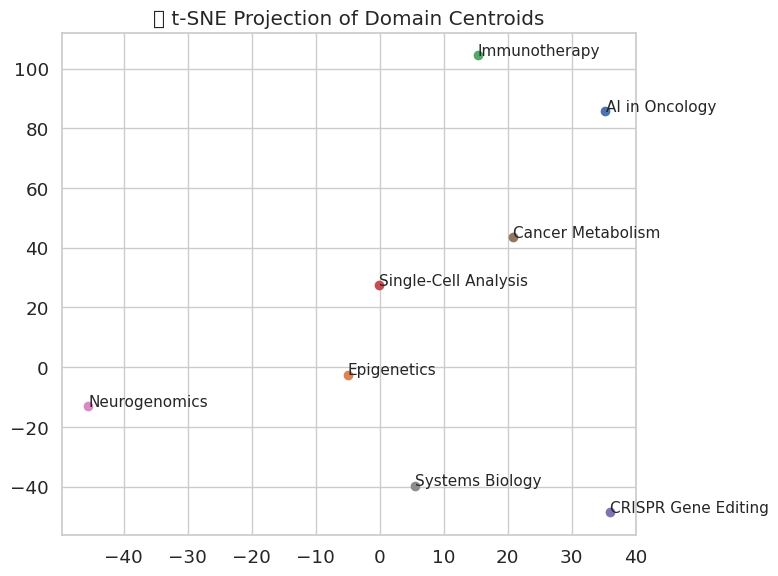

In [125]:
domain_vectors = compute_domain_centroids(df, specter_embeddings)
plot_centroid_tsne(domain_vectors)


In [127]:
# specter_embeddings değişkenini .npy dosyasına kaydet
np.save("specter_embeddings.npy", specter_embeddings)
from google.colab import files
files.download("specter_embeddings.npy")
